<div style="background-color:#235543; color:white; padding:10px; border-radius:5px; font-size:30px;">
<strong>Business Problem Statement</strong>
</div>

**ConnectTel Communications Ltd,** a pan-India telecom operator offering mobile, broadband, and bundled data plans to both prepaid and postpaid customers, is experiencing a significant and sustained increase in customer churn, particularly among high-value segments such as heavy data users and long-tenure postpaid customers. This customer attrition is negatively affecting the company's revenue, market position, and future expansion. The current method for addressing this issue is primarily reactive and fails to capture the complexity of customer behavior.

Despite ongoing investments in discounting strategies, bundled offerings, and promotional campaigns, the organization faces critical gaps in its current retention approach: 
- *Lack of proactive churn identification -* Customers are being engaged only after they initiate port-out or disconnection requests.
- *Silent churn behavior -* High-value customers are leaving without explicit complaints or warning signals.
- *Limited understanding of churn drivers -* Insufficient insight into behavioral, service-related, and financial triggers behind churn.
---

<div style="background-color:#235543; color:white; padding:10px; border-radius:5px; font-size:18px;">
<strong>Core Business Objective</strong>
</div>

The primary objective is to **develop a data-driven, predictive churn management system** that enables ConnectTel to:
- **1. Accurately identify customers at high risk of churn in the near future.**
- **2. Diagnose key drivers of churn (e.g., poor service experience, billing shocks, price dissatisfaction, low engagement).**
- **3. Enable targeted, proactive retention strategies** to reduce and protect revenue.

---

<div style="background-color:#235543; color:white; padding:10px; border-radius:5px; font-size:18px;">
<strong>Expected Business Impact</strong>
</div>

A successful solution delivers measurable improvements in:
- Early identification of high-risk customers (high recall for churners).
- Reduction in monthly churn rate across key segments (prepaid, postpaid, high-value customers).
- Improved retention efficiency by targeting only customers who are truly at risk.
- Enhanced customer lifetime value (CLV) through timely interventions.
- Optimized allocation of retention budget and operational resources.

---

<div style="background-color:#235543; color:white; padding:10px; border-radius:5px; font-size:18px;">
<strong>Technical Data for Analysis</strong>
</div>

Our analysis will be based on historical data collected on customer behavior and service usage from the **telecom_churn.csv** dataset, which includes:

**1. Customer Demographics and Plan Details**
- **customer_id:** Unique identifier for each customer.
- **gender, age:** Demographic attributes used to identify churn patterns across customer groups.
- **region_circle:** Customer's service region (North/South/East/West/Metro), impacting usage behavior and churn drivers.
- **connection_type:** Type of service (4G/5G/Fiber Home Broadband), influencing usage behavior and churn drivers.
- **plan_type:** Prepaid or Postpaid plan classification.
- **contract_type:** Subscription commitment (No Contract / 1 Year / 2 Year / Month-to-Month).
- **base_plan_category:** Pricing tier (Prepaid Mini / Prepaid Regular /  Prepaid Unlimited / Postpaid Silver / Postpaid Gold / Postpaid Platinum).
- **tenure_months:** Duration of customer relationship with the company.

**2. Usage and Billing Behavior** 
- **monthly_charges:** Monthly billing amount.
- **total_charges:** Lifetime value generated by the customer.
- **avg_data_gb_month:** Average monthly data consumption.
- **avg_voice_mins_monthly:** Average voice usage.
- **sms_count_month:** Monthly SMS usage.
- **overage_charges:** Additional charges beyond subscribed plan.

**3. Service Adoption and Product Engagement**
- **is_family_plan:** Whether customer is part of a bundled family plan.
- **is_multi_service:** Subscription to multiple services (e.g., mobile + broadband).
- **app_login_30d:** Frequency of mobile app usage in last 30 days.
- **selfcare_transactions_30d:** Self-service portal activity.

**4. Network Quality and Service Experience**
- **network_issues_3m:** Number of network-related issues reported in last 3 months.
- **dropped_call_rate:** Percentage of dropped calls.
- **avg_data_speed_mbps:** Average internet speed experience.
- **num_complaints_3m, num_complaints_12m:** Short-term and long-term complaints count.
- **call_center_interactions_3m:** Number of customer support interactions.
- **last_complaint_resolution_days:** Time taken to resolve recent issues.

**5. Payment Behavior and Financial Indicators**
- **auto_pay_enrolled:** Whether customer uses auto payment.
- **late_payment_flag_3m:** Indicator of recent delayed payments.
- **avg_payment_delay_days:** Average delay in bill payments.
- **arpu:** Average revenue per user.
- **segment_value:** Customer value classification (Low / Medium / High).

**6. Customer Sentiment and Competitive Signals**
- **nps_score:** Net promoter score reflecting customer loyalty.
- **service_rating_last_6m:** Average service satisfaction rating.
- **received_competitor_offer_flag:** Indicates competitive churn pressure.
- **retention_offer_accepted_flag:** Whether customer previously accepted a retention offer.

**7. Target Variable**
- **is_churn:** Binary variable indicating whether the customer has churned (1 = churned, 0 = retained).

---

<div style="background-color:#235543; color:white; padding:10px; border-radius:5px; font-size:30px;">
<strong>PROJECT EXECUTION</strong>
</div>

### **Import Libraries**

In [1]:
# ============================================================================
# 1. IMPORT LIBRARIES
# ============================================================================
print('Importing Libraries...')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prettytable import PrettyTable


from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, precision_score, recall_score, f1_score
import joblib

import warnings
warnings.filterwarnings('ignore')

print('\nLibraries are imported successfully.')

Importing Libraries...

Libraries are imported successfully.


### **Read the Data & EDA**

In [2]:
# ============================================================================
# 2. LOAD DATA & EDA
#=============================================================================

# Read the csv file:
data = pd.read_csv('telecom_churn.csv')
print('\nData has been loaded successfully.')

# Display the first few rows to verify it's loaded successfully:
data.head()


Data has been loaded successfully.


,customer_id,gender,age,region_circle,connection_type,plan_type,contract_type,base_plan_category,tenure_months,monthly_charges,...,auto_pay_enrolled,late_payment_flag_3m,avg_payment_delay_days,arpu,segment_value,nps_score,service_rating_last_6m,received_competitor_offer_flag,retention_offer_accepted_flag,is_churn
0,100000,Female,23,West,4G,Postpaid,2 Year,Postpaid Platinum,84,1133.57,...,0,0,0.4,1133.57,High,13.0,3.2,0,0,0
1,100001,Male,72,West,4G,Prepaid,No Contract,Prepaid Unlimited,32,683.24,...,0,1,5.4,688.54,Medium,41.0,3.6,0,0,0
2,100002,Female,47,South,4G,Prepaid,No Contract,Prepaid Regular,119,307.04,...,1,0,0.0,307.05,Low,53.0,5.0,0,0,0
3,100003,Female,74,West,4G,Prepaid,No Contract,Prepaid Mini,73,213.82,...,1,0,0.0,214.89,Low,20.0,4.5,1,1,0
4,100004,Male,41,South,5G,Prepaid,No Contract,Prepaid Regular,92,383.17,...,0,0,0.5,383.99,Low,17.0,2.6,0,0,0


In [3]:
print('\n--- CHECKING FOR DUPLICATED DATA ---')
duplicates = data.duplicated().sum()
if duplicates == 0:
    print('No duplicate records found. Each record is a unique entry.')
else:
    data = data.drop_duplicates()
    print(f'{duplicates} number of duplicated records removed successfully.')

print('\n--- CHECKING FOR DUPLICATES IN UNIQUE COLUMN (customer_id) ---')
cust_duplicates = data['customer_id'].duplicated().sum()
if cust_duplicates == 0:
    print("'customer_id' is unique: Every customer ID is distinct.")
else:
    print(f"WARNING: {cust_duplicates} duplicate customer IDs found.")

print('\n--- SHAPE OF THE DATASET ---')
print(f'Number of Rows:    {data.shape[0]}')
print(f'Number of Columns: {data.shape[1]}')

print('\n--- DATA TYPES AND MISSING VALUE CHECK ---')
print(data.info())

print('\n--- CHURN RATE AND CLASS BALANCE ---')
print(f'Churn Rate:    {data["is_churn"].mean() * 100:.2f}%')
print(f'Class Balance: {(data["is_churn"]==0).sum()} / {(data["is_churn"]==1).sum()} (No / Yes)')

print('\n--- DATA CONSISTENCY CHECK ---')
# total_charges should not be less than monthly_charges 
logic_err = data[data['total_charges'] < data['monthly_charges']]
print(f'Rows where total_charges < monthly_charges: {len(logic_err)}')
if len(logic_err) > 0 and logic_err['tenure_months'].mean() == 1:
    print('These are new customers (tenure = 1). Total charges may be lower than monthly charges due to partial billing cycles or initial discounts. This is expected and not a data error.')
elif len(logic_err) > 0 and logic_err['tenure_months'].mean() > 1:
    print('Data inconsistency detected: total_charges is less than monthly_charges. Requires further investigation. ')


--- CHECKING FOR DUPLICATED DATA ---
No duplicate records found. Each record is a unique entry.

--- CHECKING FOR DUPLICATES IN UNIQUE COLUMN (customer_id) ---
'customer_id' is unique: Every customer ID is distinct.

--- SHAPE OF THE DATASET ---
Number of Rows:    25000
Number of Columns: 36

--- DATA TYPES AND MISSING VALUE CHECK ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     25000 non-null  int64  
 1   gender                          25000 non-null  object 
 2   age                             25000 non-null  int64  
 3   region_circle                   25000 non-null  object 
 4   connection_type                 25000 non-null  object 
 5   plan_type                       25000 non-null  object 
 6   contract_type                   25000 non-null  object 
 7  

### Interpretation in Business Terms
---

**Number of Observations:** <br>
The dataset contains **25,000 entries (rows)**, with each entry representing a unique customer's behavioral and service usage data. This large dataset provides a foundation to build a reliable predictive model for customer churn, enabling ConnectTel to make informed, data-driven decisions affecting a significant portion of its customer base.

**Column Data Types and Usage:**
The dataset comprises **36 columns**, capturing key aspects of customer demographics, behavioral features, service usage, and support interactions.

- **Object types**, such as **plan_type**, **contract_type**, **connection_type**, represent categorical data. These require **one-hot encoding** to be converted into numerical format that the machine learning model can process. These features are important for segmenting customers and understanding how service plans influence churn risk.
- **Numerical types** (integer/float), like **tenure_months**, **monthly_charges**, and **avg_data_gb_month**, provide direct quantitative measures of customer loyalty and engagement. They could be the key features for machine learning models to identify thresholds and patterns that lead to churn.
- The **Target Variable**, **'is_churn'**, is a binary variable (1/0), making it a classic **binary classification** task, which aligns perfectly with our prediction goal.



**Missing Data Check:**
- A preliminary review shows there is no missing data in any column.



**Memory Usage:**
The dataset occupies approximately **7.0 MB**, making it lightweight and easy to manage. This ensures efficient data processing and model training without the need for specialized high-performance computing resources.

---

### **General Exploratory Data Analysis (EDA):**


--- NUMERIC FEATURES SUMMARY AND VISUALIZATION ---
+--------------------------------+---------+----------+----------+--------+-----------+-----------+
|            Feature             |   Mean  |  Median  | Std dev  |  Min   |    Max    | Missing_% |
+--------------------------------+---------+----------+----------+--------+-----------+-----------+
|              age               |  45.96  |   46.0   |   16.4   |   18   |     74    |    0.0    |
|         tenure_months          |  60.15  |   60.0   |  34.37   |   1    |    119    |    0.0    |
|        monthly_charges         |  475.52 |  385.74  |  267.55  |  99.0  |  1603.49  |    0.0    |
|         total_charges          | 27230.7 | 20840.65 | 23717.16 | 159.03 | 177878.03 |    0.0    |
|       avg_data_gb_month        |  25.11  |   25.1   |   9.91   |  0.5   |    71.8   |    0.0    |
|      avg_voice_mins_month      |  602.19 |  603.0   |  247.93  |  30.0  |   1848.0  |    0.0    |
|        sms_count_month         |  50.65  |   5

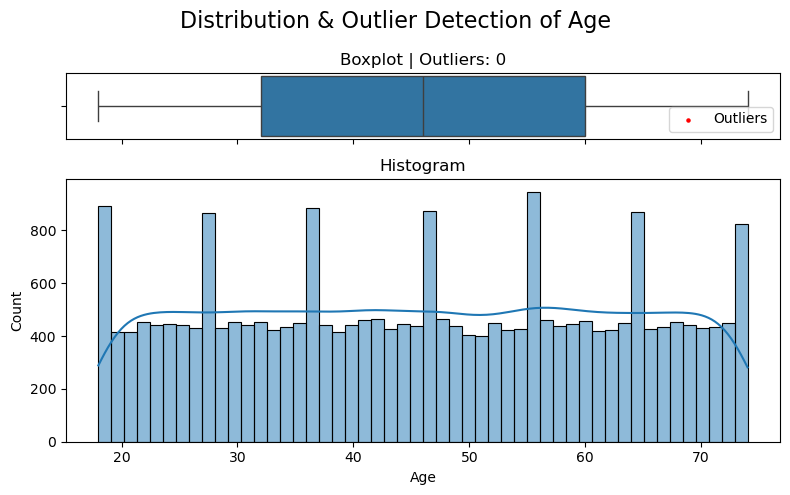

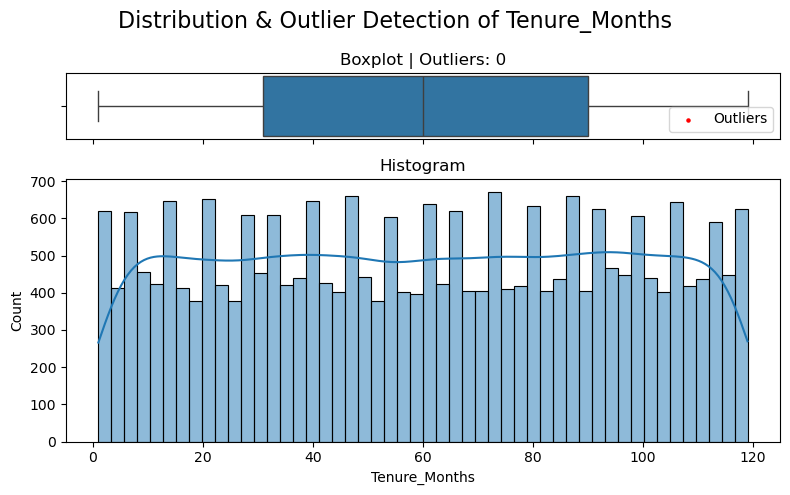

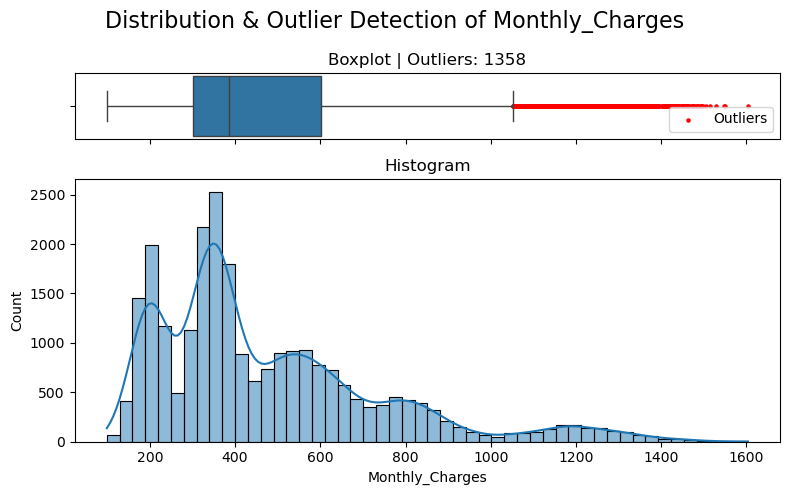

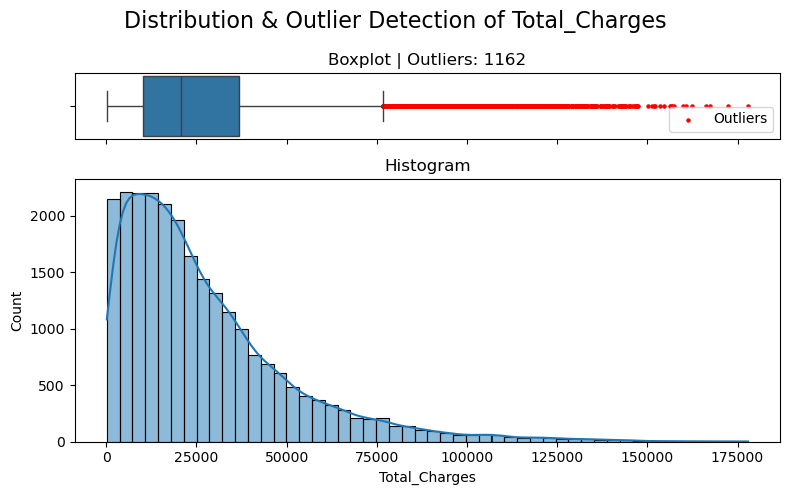

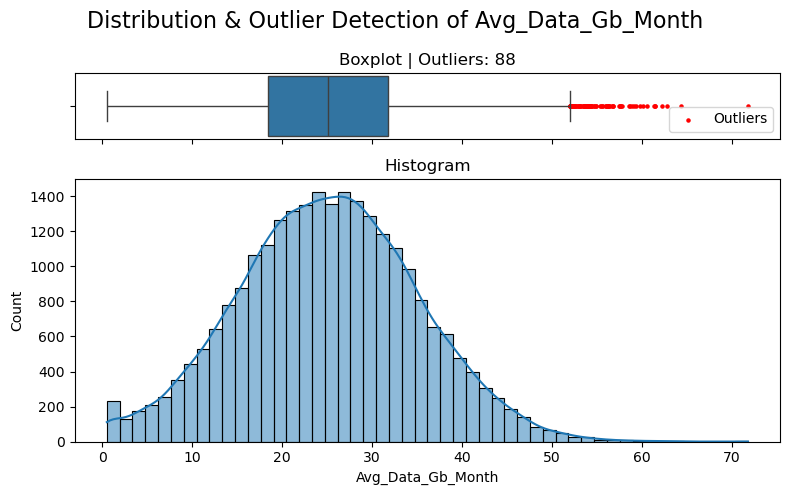

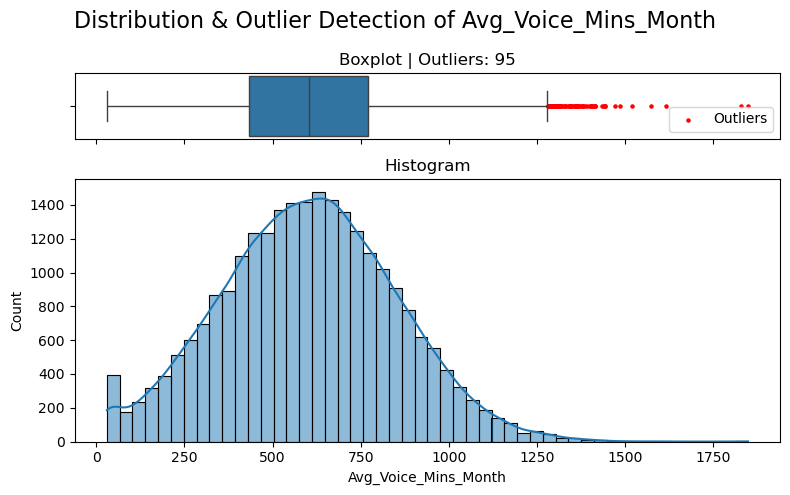

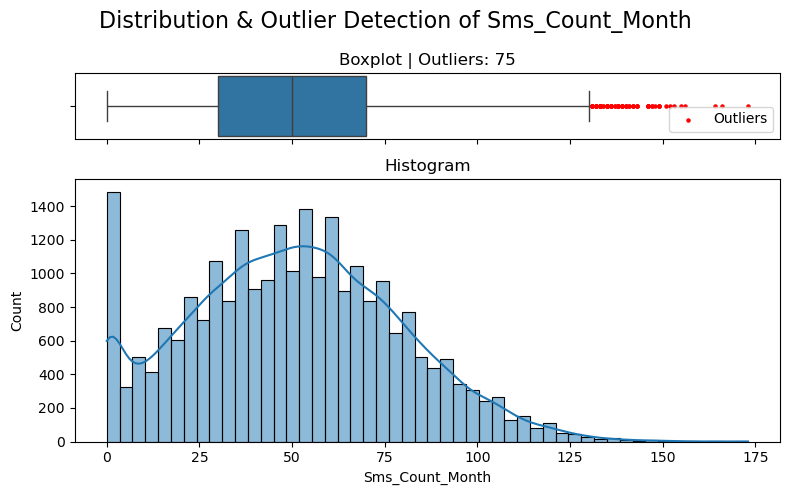

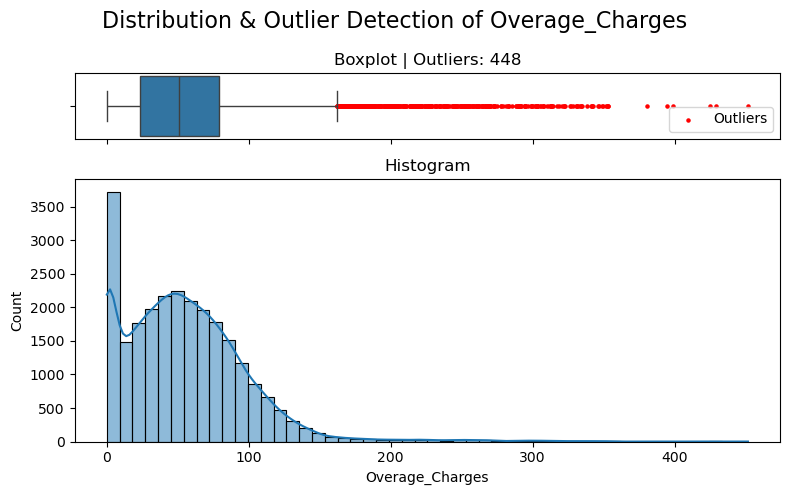

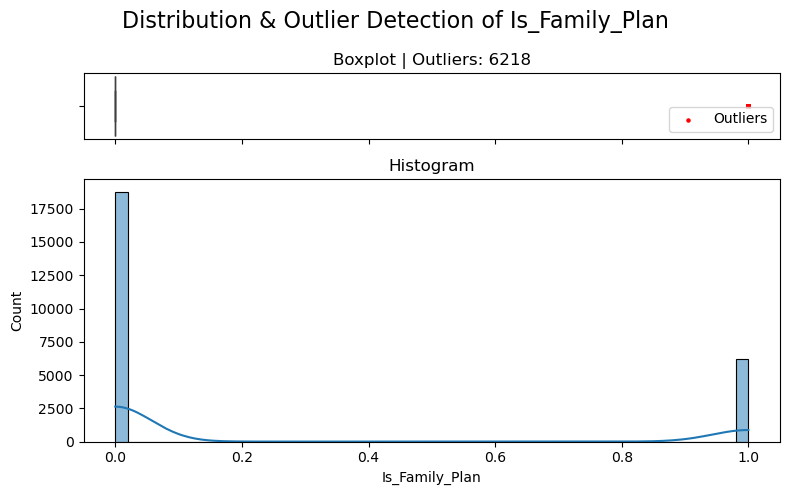

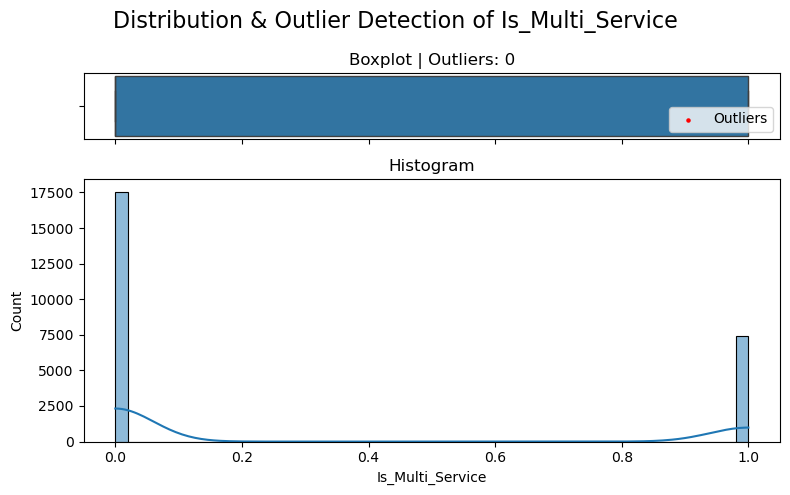

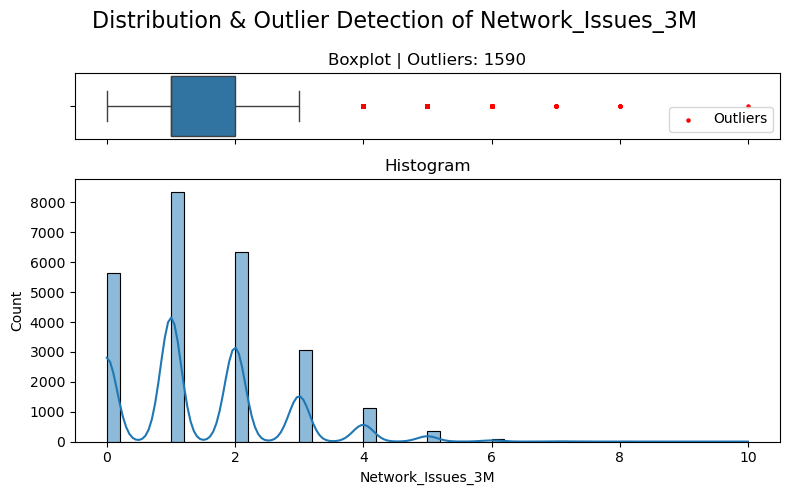

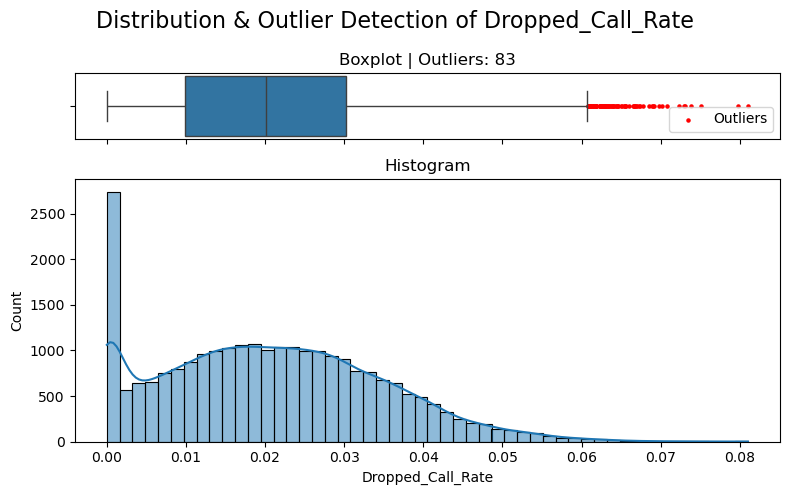

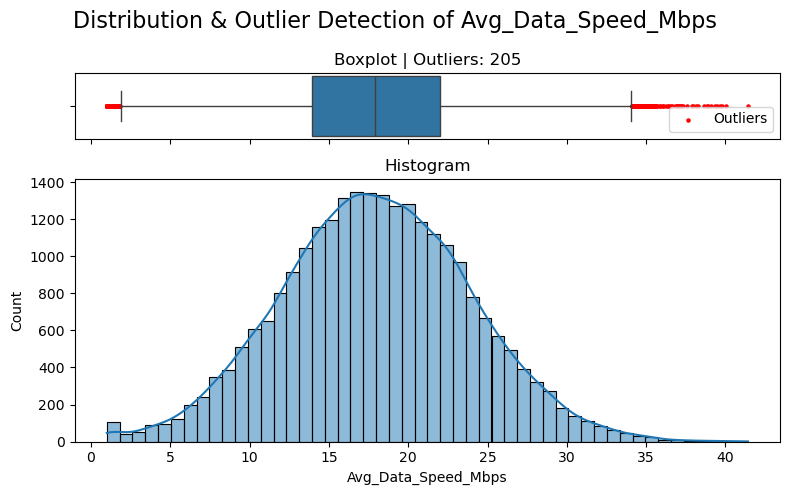

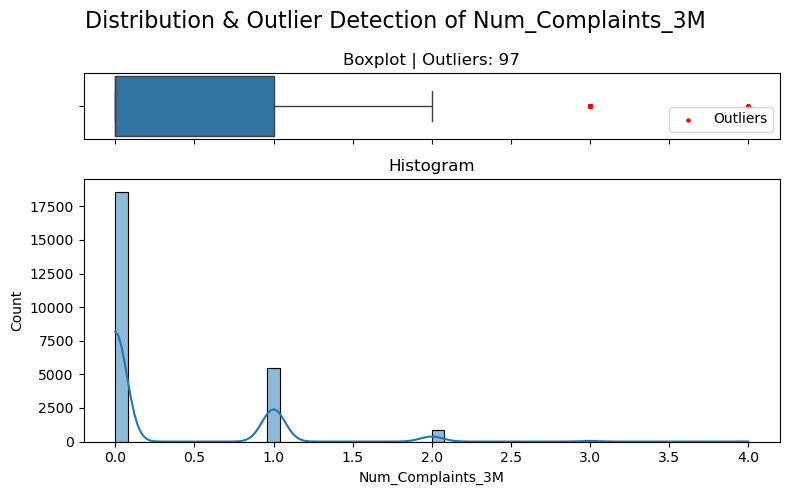

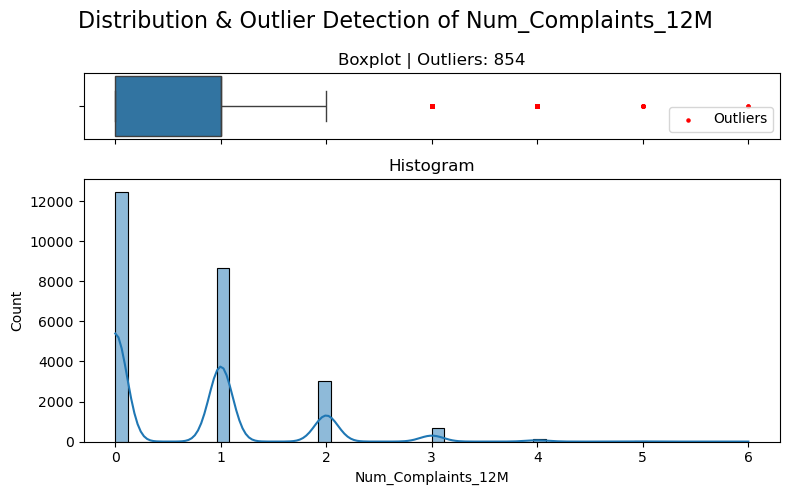

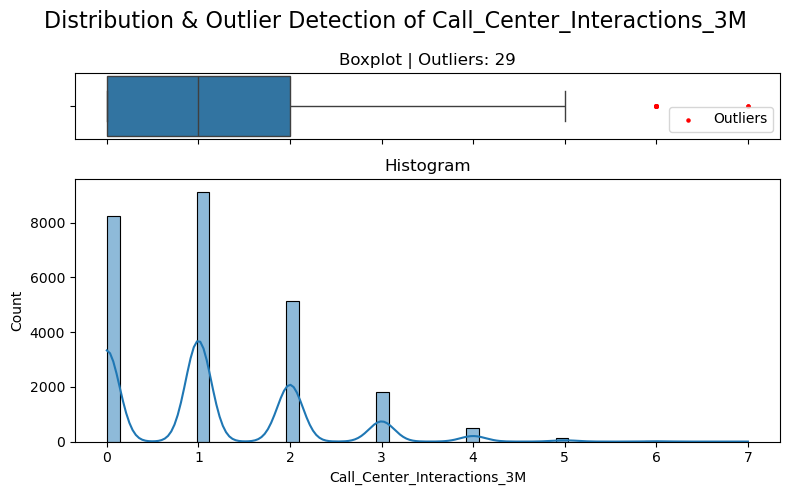

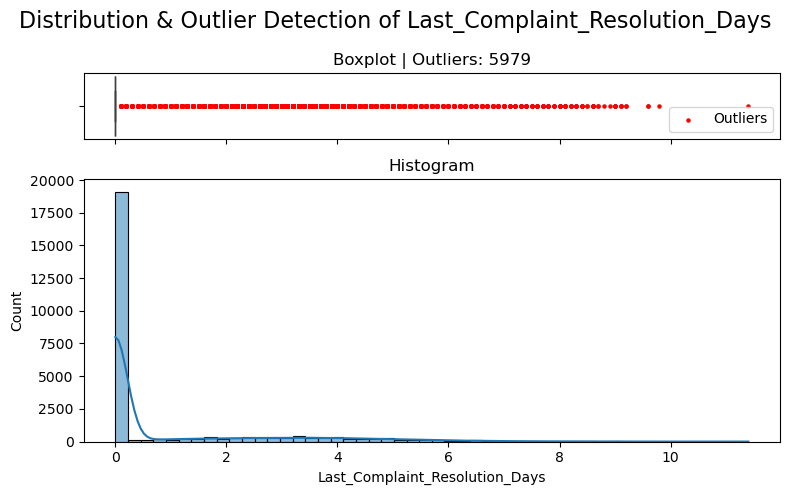

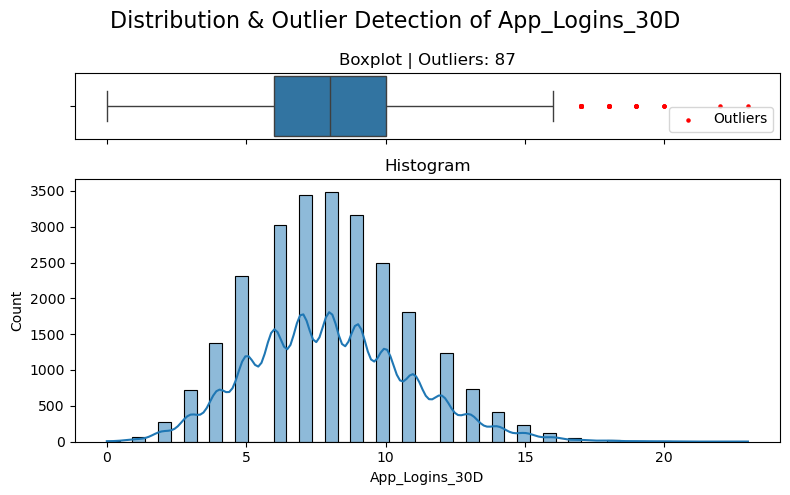

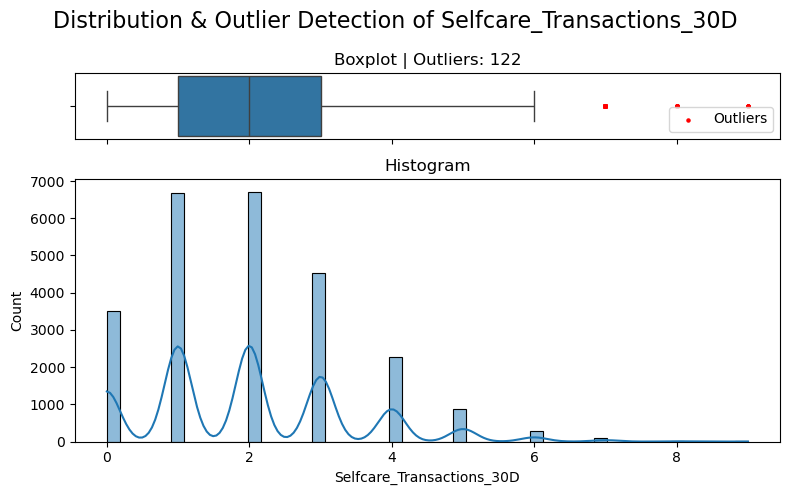

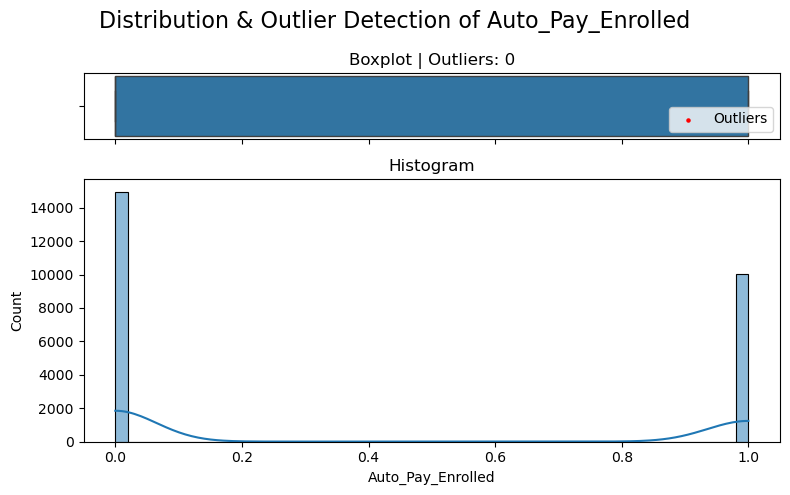

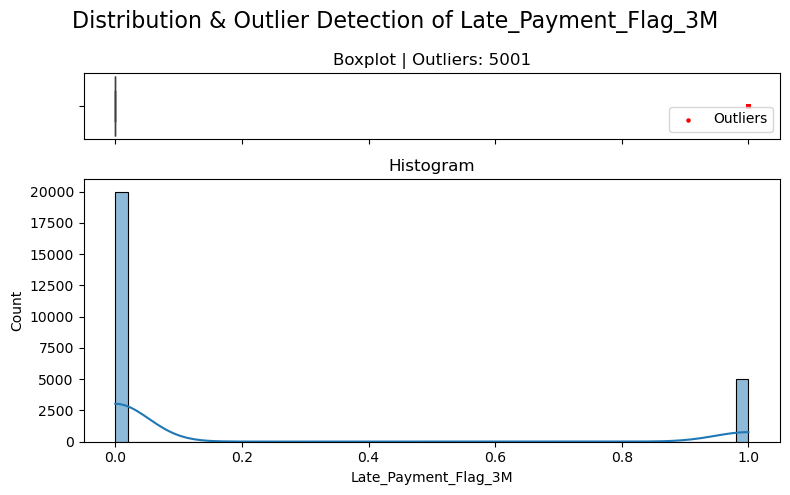

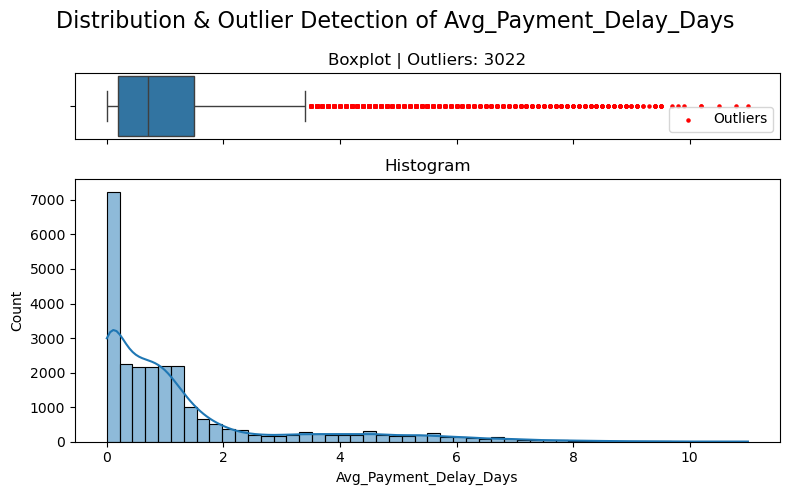

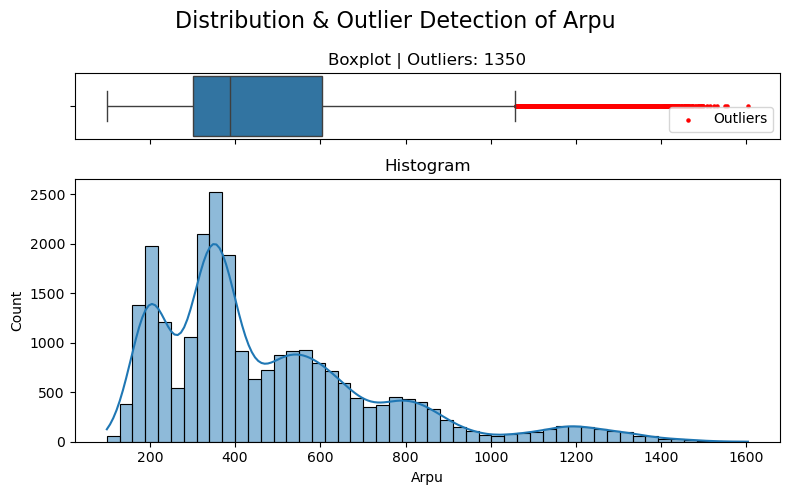

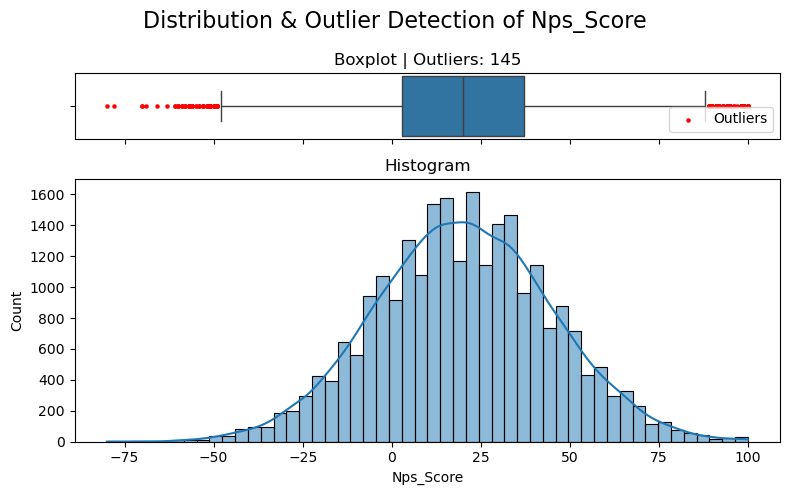

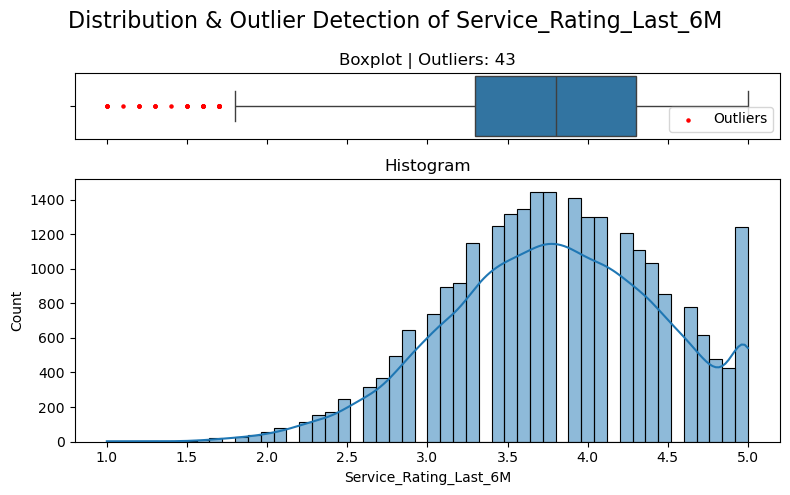

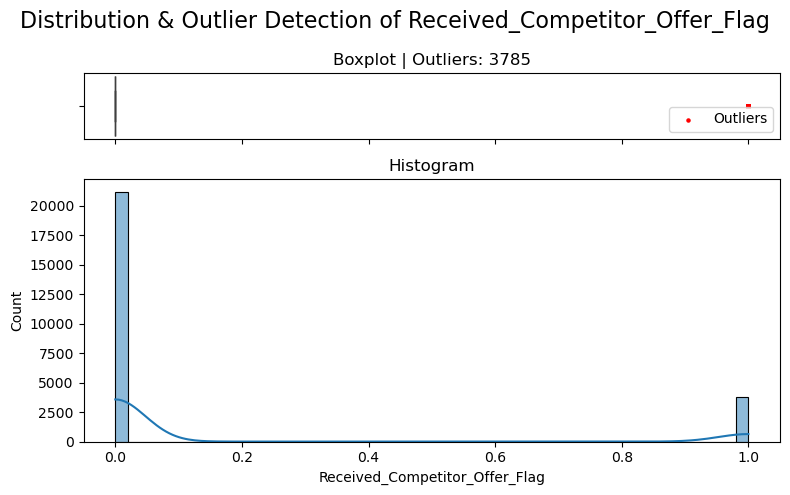

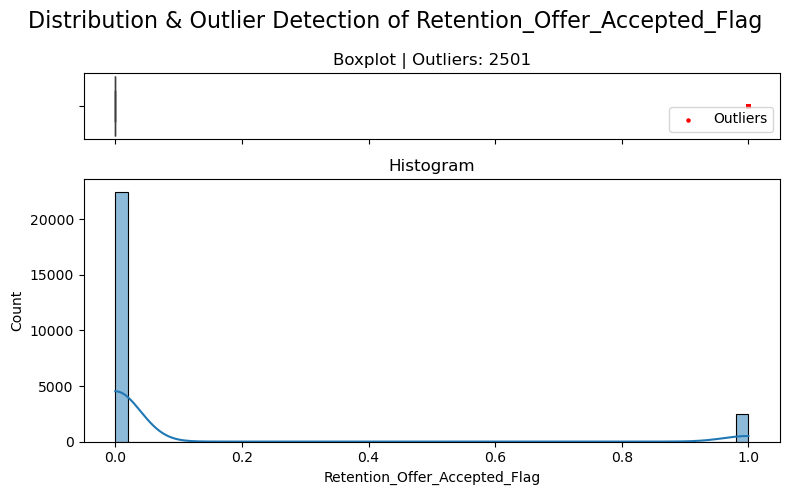

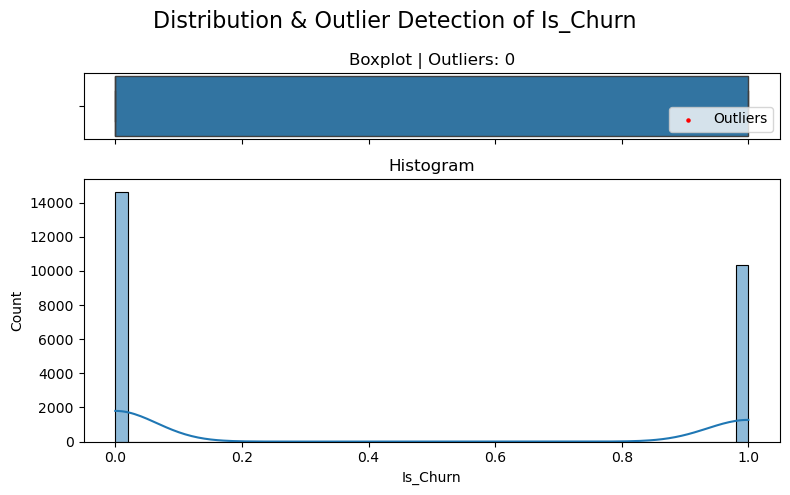

In [4]:
# Dropping 'customer_id' column as it has no significance in further analysis.
df = data.drop('customer_id', axis = 1)

# Define numeric and categorical columns for detailed statistical analysis:
numerical_columns = df.select_dtypes(include = ['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include = ['object']).columns

# ----------------------------------------------------------------------------
# Numeric Features EDA
# ----------------------------------------------------------------------------
# Initialize PrettyTable to display numeric summaries clearly
summary_table_numeric = PrettyTable()

# Define column headers for PrettyTable:
summary_table_numeric.field_names = ['Feature', 'Mean', 'Median', 'Std dev', 'Min', 'Max', 'Missing_%']

# Loop through each numerical column to calculate summary statistics:
for col in numerical_columns:
    mean_val = round(df[col].mean(), 2)
    median_val = round(df[col].median(), 2)
    std_dev = round(df[col].std(), 2)
    min_val = round(df[col].min(), 2)
    max_val = round(df[col].max(), 2)
    missing = round(df[col].isnull().mean()*100, 2)

    # Add the calculated statistics to PrettyTable
    summary_table_numeric.add_row([col, mean_val, median_val, std_dev, min_val, max_val, missing])

# Display the PrettyTable with numeric summary statistics
print('\n--- NUMERIC FEATURES SUMMARY AND VISUALIZATION ---')
print(summary_table_numeric)

# Generate histograms with boxplot for each numeric feature
for col in numerical_columns:
    fig, ax = plt.subplots(2, 1, figsize = (8,5),
                          gridspec_kw = {'height_ratios':[1,4]},
                          sharex = True)
    # Plotting boxplot:
    sns.boxplot(x = col, data = df, showfliers = False, ax = ax[0])
    # Calculate IQR threshold to identify outliers threshold:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr
    # Identify and overlay outliers as red dots
    outliers = df[(df[col]<lower_bound) | (df[col]>upper_bound)][col]
    ax[0].scatter(outliers, [0]*len(outliers), color = 'Red', label = 'Outliers', s=5)
    ax[0].set_title(f'Boxplot | Outliers: {len(outliers)}')
    ax[0].legend(loc = 'lower right')

    sns.histplot(x=col, data=df, bins=50, kde=True)
    ax[1].set_title('Histogram')
    ax[1].set_xlabel(col.title())
    ax[1].set_ylabel('Count')

    fig.suptitle(f'Distribution & Outlier Detection of {col.title()}',fontsize = 16)
    plt.tight_layout()
    plt.show()


--- CATEGORICAL FEATURE SUMMARY AND VISUALIZATION ---

Value Count for gender:
   gender  counts
0  Female   12070
1    Male   11940
2   Other     990


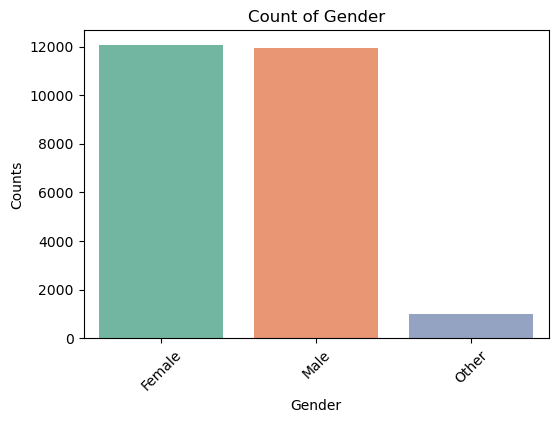


Value Count for region_circle:
  region_circle  counts
0         North    5615
1         South    5382
2         Metro    4961
3          East    4578
4          West    4464


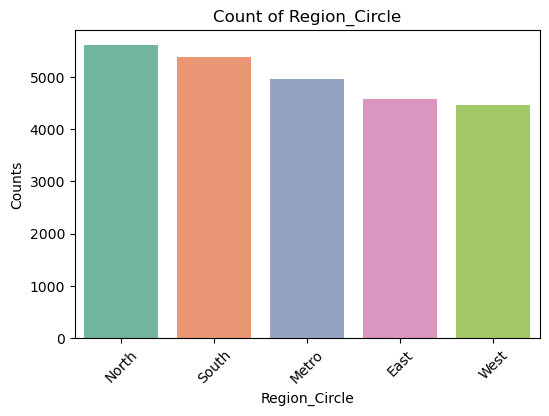


Value Count for connection_type:
        connection_type  counts
0                    4G   12518
1                    5G    7503
2  Fiber Home Broadband    4979


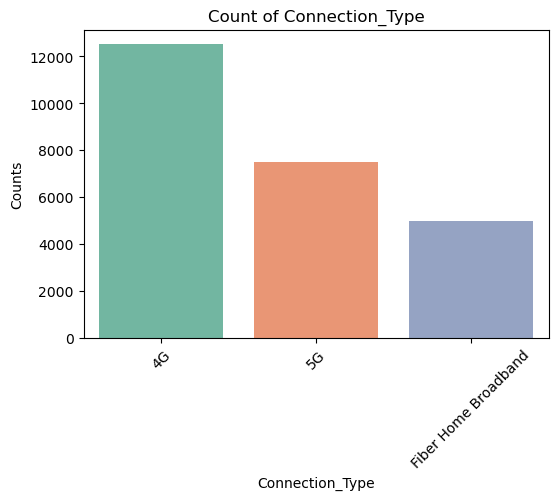


Value Count for plan_type:
  plan_type  counts
0   Prepaid   17522
1  Postpaid    7478


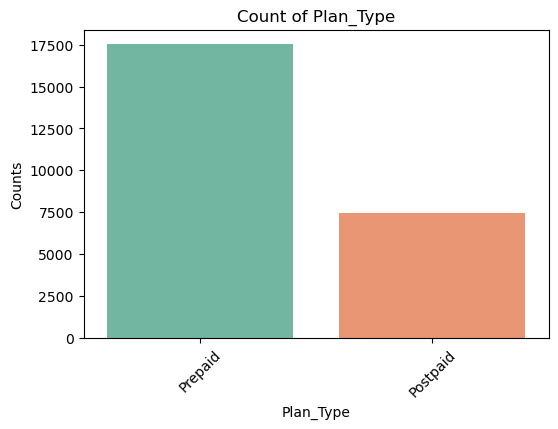


Value Count for contract_type:
    contract_type  counts
0     No Contract   17522
1  Month-to-Month    4589
2          1 Year    2147
3          2 Year     742


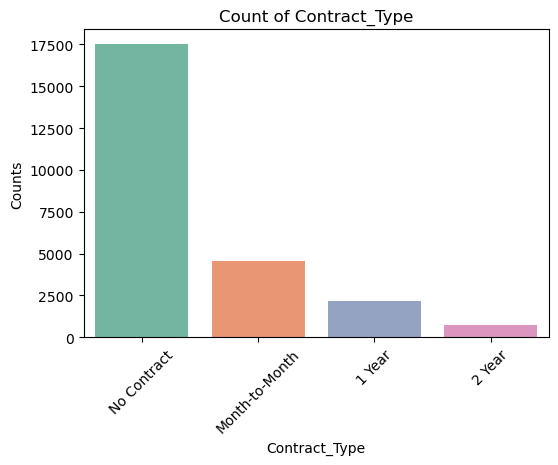


Value Count for base_plan_category:
  base_plan_category  counts
0    Prepaid Regular    8755
1       Prepaid Mini    5265
2  Prepaid Unlimited    3502
3      Postpaid Gold    2999
4    Postpaid Silver    2971
5  Postpaid Platinum    1508


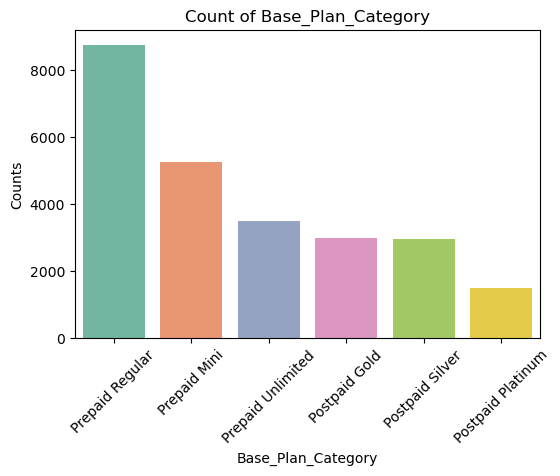


Value Count for segment_value:
  segment_value  counts
0           Low   13121
1        Medium    8850
2          High    3029


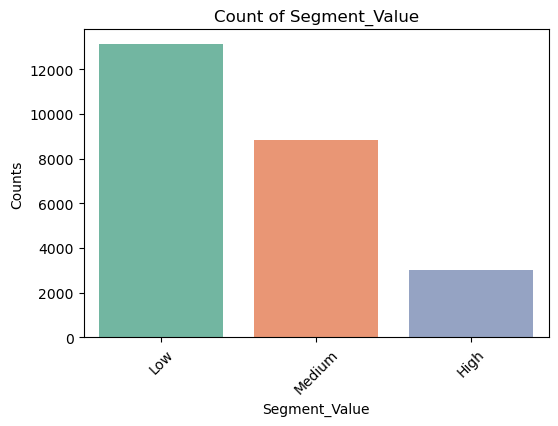

In [5]:
# -----------------------------------------------------------------------------
# Categorical Feature EDA
# -----------------------------------------------------------------------------
print('\n--- CATEGORICAL FEATURE SUMMARY AND VISUALIZATION ---')
for col in categorical_columns:
    print(f'\nValue Count for {col}:')
    counts = df[col].value_counts().sort_values(ascending=False).reset_index()
    counts.columns = [col, 'counts']
    print(counts)

    plt.figure(figsize = (6,4))
    sns.barplot(x = col, y = 'counts', data = counts, palette = 'Set2')
    plt.title(f'Count of {col.title()}')
    plt.xlabel(col.title())
    plt.ylabel('Counts')
    plt.xticks(rotation = 45)
    plt.show()


--- CHURN ANALYSIS BY CATEGORICAL FEATURES ---

Churn Analysis by Gender:
        customers  churn_rate  avg_arpu  monthly_revenue_at_risk
gender                                                          
Male        11940       0.418   476.569              2378517.753
Female      12070       0.414   478.988              2393493.456
Other         990       0.382   482.661               182532.737


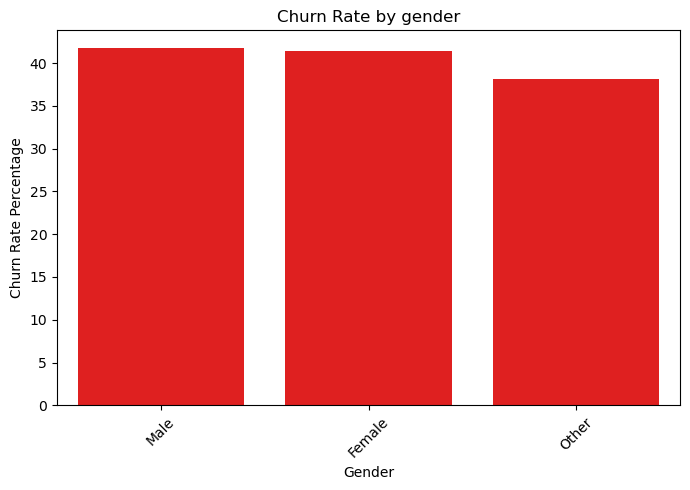


Churn Analysis by Region_Circle:
               customers  churn_rate  avg_arpu  monthly_revenue_at_risk
region_circle                                                          
Metro               4961       0.422   477.016               998653.031
East                4578       0.416   478.738               911731.627
West                4464       0.416   472.838               878071.514
North               5615       0.410   477.821              1100015.615
South               5382       0.410   482.645              1065014.110


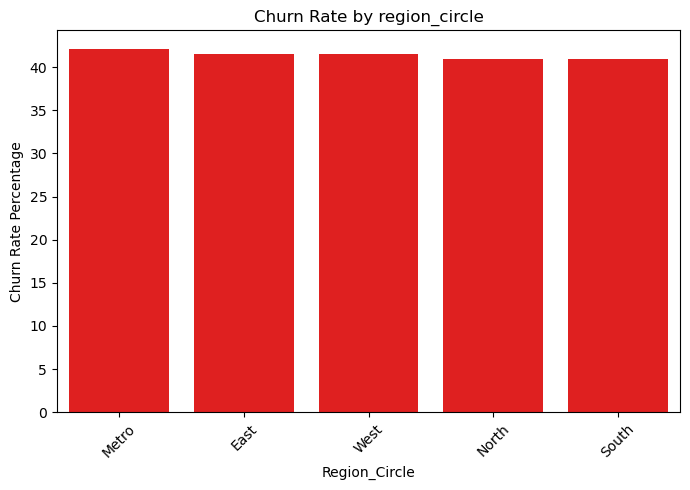


Churn Analysis by Connection_Type:
                      customers  churn_rate  avg_arpu  monthly_revenue_at_risk
connection_type                                                               
Fiber Home Broadband       4979       0.421   482.524              1011447.025
5G                         7503       0.416   478.794              1494434.815
4G                        12518       0.411   475.681              2447330.226


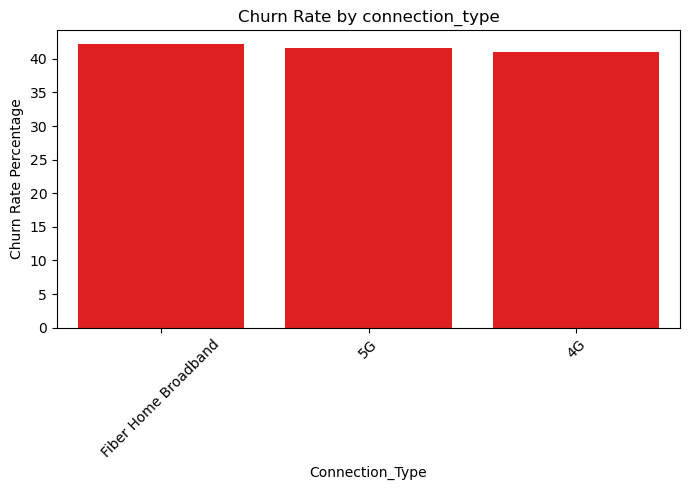


Churn Analysis by Plan_Type:
           customers  churn_rate  avg_arpu  monthly_revenue_at_risk
plan_type                                                          
Prepaid        17522       0.457   356.025              2850889.413
Postpaid        7478       0.314   763.731              1793310.651


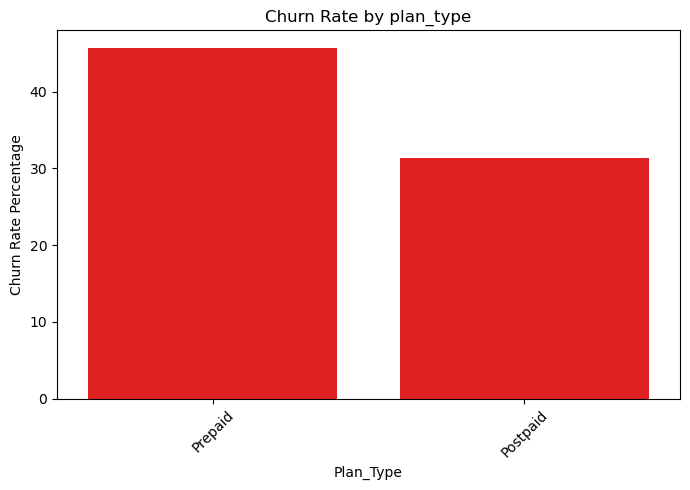


Churn Analysis by Contract_Type:
                customers  churn_rate  avg_arpu  monthly_revenue_at_risk
contract_type                                                           
No Contract         17522       0.457   356.025              2850889.413
Month-to-Month       4589       0.328   762.504              1147714.921
1 Year               2147       0.312   766.468               513429.320
2 Year                742       0.233   763.398               131980.827


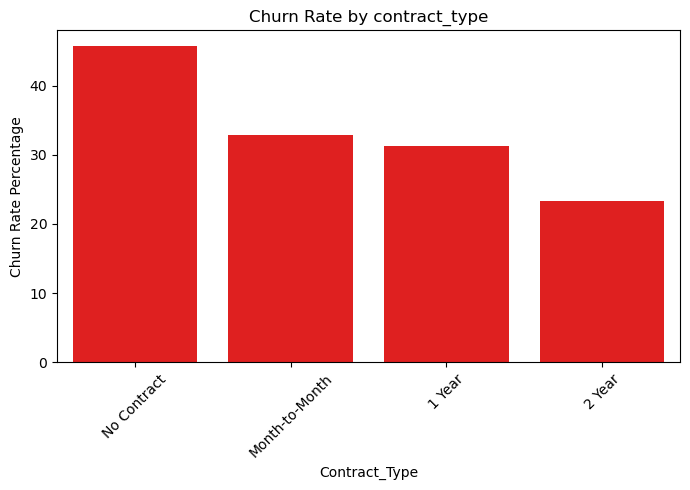


Churn Analysis by Base_Plan_Category:
                    customers  churn_rate  avg_arpu  monthly_revenue_at_risk
base_plan_category                                                          
Prepaid Unlimited        3502       0.477   600.963              1003881.047
Prepaid Mini             5265       0.458   201.369               485575.166
Prepaid Regular          8755       0.448   351.056              1376925.885
Postpaid Silver          2971       0.321   500.361               477189.782
Postpaid Gold            2999       0.312   802.934               751295.709
Postpaid Platinum        1508       0.305  1204.648               554065.801


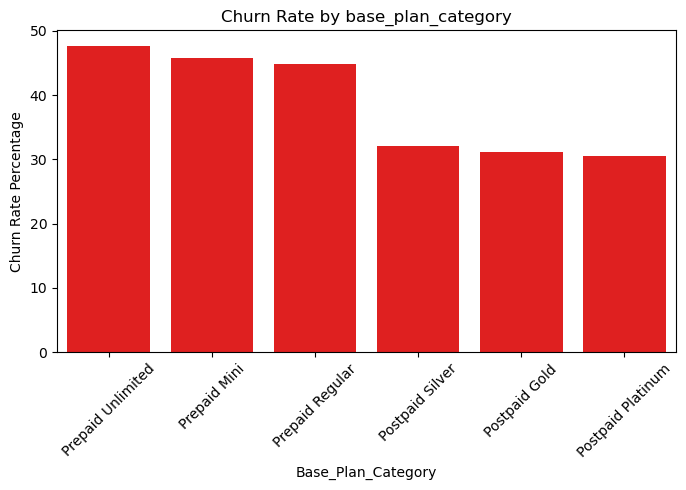


Churn Analysis by Segment_Value:
               customers  churn_rate  avg_arpu  monthly_revenue_at_risk
segment_value                                                          
Low                13121       0.452   285.947              1695863.585
Medium              8850       0.393   571.887              1989051.580
High                3029       0.311  1035.437               975401.327


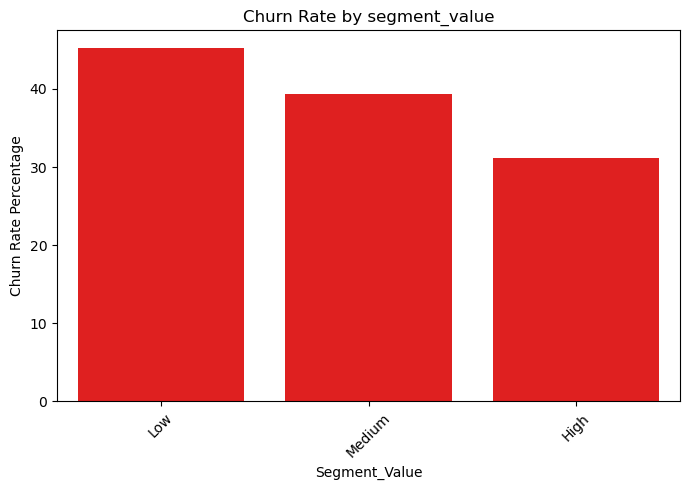

In [6]:
# -----------------------------------------------------------------------------
# Churn Rate Analysis by Categorical Features
# -----------------------------------------------------------------------------
print('\n--- CHURN ANALYSIS BY CATEGORICAL FEATURES ---')
for col in categorical_columns:
    stats = df.groupby(col).agg(
        customers = ('is_churn', 'size'),
        churn_rate = ('is_churn', 'mean'),
        avg_arpu = ('arpu', 'mean')
    ).round(3)
    stats['monthly_revenue_at_risk'] = round(stats['customers'] * stats['churn_rate']
                                             * stats['avg_arpu'], 3)
    stats = stats.sort_values(by = 'churn_rate', ascending = False)
    print(f'\nChurn Analysis by {col.title()}:')
    print(stats.to_string())

    # Visualization:
    churn_rate = df.groupby(col)['is_churn'].mean().reset_index()
    churn_rate['is_churn'] = round(churn_rate['is_churn']*100, 2)
    churn_rate.rename(columns = {'is_churn':'churn_rate_%'}, inplace = True)
    churn_rate = churn_rate.sort_values(by = 'churn_rate_%', ascending = False)

    plt.figure(figsize = (7,5))
    sns.barplot(x = col, y = 'churn_rate_%', data = churn_rate, color = 'Red')
    plt.title(f'Churn Rate by {col}')
    plt.xlabel(col.title())
    plt.ylabel('Churn Rate Percentage')
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

#### **Business Interpretation of EDA Results**

---

**1. Numeric Features Summary Table:**<br>
The summary table provides crucial insights into ConnectTel's customer base. The average customer has been with the company for about 60 months, indicating a **fairly stable, long-term customer base.** However the median 'tenure_months' is also 60, suggesting a balanced distribution without a strong skew.

The company has balanced distribution of customer age meaning the company caters to a **diverse demographic rather than a specific age group.** 

The monthly_charges and total_charges show that the average customer is billed around Rs.475/- per month, accumulating to an average total of Rs.27230/-. This highlights the value of customer base. But **there is a huge gap between low-value and high-value customers.** High-value customers should have priority for retention and low value customers provide upsell opportunity.

The average data usage by customer is 25GB per month with minimum data usage being 0.5GB which could either indicate **low engagement or potential service issue** require further investigation. The **maximum data usage is 71GB per month** indicating heavy users, these are **company's premium customers** who should be retained. Voice and SMS usage also vary significantly meaning customers are not uniform, **there exist multiple usage personas.**

Customer faces an average of 1.5 network issues in last 3 months, some experience call drops and low data speeds, complaints exist but are concentrated in a smaller segment. **Service quality is inconsistent across users** which is a **direct churn driver.**

NPS score averages 20 which is low and service rating is also 3.8/5 meaning **customers are not highly satisfied.** 'Okay' customers are easy to lose.

20% customers delay payments, and only 40% use auto-pay meaning many **customers are not financially or behaviorally committed strongly.**

Moderate app usage around 8 logins/month and low self-service transactions(2/month). **Customers are not deeply engaged.** Low engagement means weak relationship with brand and easier to churn.

About 15% customers received competitor offers, **competitors are actively targeting customers.** Only 10% customers accepted retention offers meaning **retention strategies are not fully effective.**

**Churn rate is very high 41%**, representing a major revenue and growth challenge for the company.

---


**2. Distribution of tenure_months:** <br>
The histogram for tenure_months shows relatively uniform distribution. This is a positive finding as it indicates a healthy mix of new, medium-term, and long-term customers. However, the large number of customers with low tenure (1-20 months) represent a high-risk group. The Machine Learning model must focus on identifying the factors that cause new customers to leave early. The fact that significant number of customers stay for a long period (100-120 months) is a testament to the company's ability to retain loyal customers.

---

**3. Distribution of monthly_charges:** <br>
The distribution of monthly_charges is right skewed, with a majority of customers clustered in the lower to mid pricing range(approximately Rs.200/- to Rs.600), while a smaller segment pays significantly higher charges. The presence of long right tail and a large number of outliers(1358) indicates a group of **high-paying customers**, likely subscribed to premium plans or bundled services. This suggests that while the company serves a broad pricing spectrum, most customers fall into **affordable or mid-tier plans**, making pricing accessible to a wider audience. From a business perspective, the high-value segment(outliers) represents **premium customers contributing disproportionately to revenue**, and therefore should be a key focus for retention. From a churn standpoint, higher monthly charge could act as a **potential churn driver** if customers feel the value received(in terms of service quality, speed, or benefits) does not justify the cost. At the same time, very low-paying customers may also churn easily due to **low engagement or low switching cost.**

---

**4. Distribution of total_charges:** <br>
The distribution of total_charges is highly right skewed, with most customers concentrated in the lower to mid range, while a smaller segment accumulates very high total charges. The large number of outliers(1162) represents customers who have contributed significantly higher revenue over time. This pattern is expected because total charges are directly influenced by **tenure and monthly billing**, meaning long-term and high-paying customers naturally appear in the higher range. Customers with high total charges are likely **long-tenure and high-value customers**, making them extremely important for the company's revenue stability. On the other hand, customers with low total charges may either be **newly acquired or low-engagement users.**

---

**5. Distribution of avg_data_gb_month(average data usage):** <br>
The distribution of average data usage appears approximately normal, with most customers clustered around the mid range(roughly 20-30GB per month). This indicates that the majority of the users have **moderate and consistent data consumption patterns**. A smaller number of outliers(88) exist on the higher end, representing **heavy data users**, while very low usage customers form a small segment on the lower end. This suggests that the company's offerings are well aligned with the need of **average user**, but there are clearly identifiable segments of both **low-engagement users and high-value heavy users.**

---

**6. Distribution of avg_voice_mins_month(average voice usage):** <br>
The distribution of average voice usage is approximately bell shaped, with most customers concentrated in the mid-range(around 400-800 minutes per month). This indicates that the majority of users have **consistent and moderate calling behavior.** A small number of outliers(95) exist on the higher end, representing **heavy voice users**, while very low usage customers form a smaller segment. This suggests that voice services are still relevant for a significant portion of customers, but usage patterns vary enough to indicate **different customer segments based on calling behavior.**

---

**7. Distribution of sms_count_month(SMS usage):** <br>
The distribution of SMS usage is slightly right-skewed, with most customers clustered in the mid range(around 30-70 messages per month). However, there is also a noticeable segment of customers with **very low or near-zero usage**, along with a small number of high-usage outliers(75). This indicates that while SMS is still used by a portion of customers, it is **not a primary communication channel for many**, likely due to the increasing use of internet-based messaging apps.

---

**8. Distribution of overage_charges:** <br>
The distribution of overage charges is highly right-skewed, with a large proportion of customers incurring **low or zero extra charge**, while smaller segment pays significantly higher overage amounts. The presence of outliers(448) indicates customers who frequently exceed their plan limits. This suggests the most customers are either on **well-matched plans** or do not heavily exceed their usage limits. However, a specific segment consistently incurs additional costs, likely due to **high usage or inadequate plan selection.**

---

**9. Distribution of network_issues_3m(network issues in last 3 months):** <br>
The distribution of network issues is right skewed, with most customers experiencing **low to moderate issues(0-3 incidents)** in the last 3 months. However, there is a noticeable tail of customers facing **frequent issues**, with some extreme cases(outliers up to 10 issues). This indicates while the majority of customers receive **acceptable service quality**, a smaller segment is significantly impacted by ***repeated network problems**.

---

**10. Distribution of dropped_call_rate:** <br>
The distribution of dropped_call_rate is right skewed, with most customers experiencing **low call drop rates(around 1%-3%)**, indicating generally acceptable voice service quality. However, small segment of customers experiences **significantly higher drop rates**, as reflected by outliers(83). This suggests that while overall call reliability is stable for the majority, there are specific cases where customers face **poor call quality**, likely due to network issues or coverage limitations.

---

**11. Distribution of avg_data_speed_mbps(average data speed):** <br>
The distribution of average data speed is approximately normal, with most customers experiencing speed in the range of **14-22 Mbps**, indicating a generally consistent service experience for the majority of users. However, there are outliers on both ends - customers experiencing **very low speeds** as well as those receiving **exceptionally high speeds**. This suggests variability in service quality across different users or regions. Customers experiencing poor speeds are **high-risk churn candidates.**

---

**12. Distribution of num_complaints_3m(complaints in last 3 months):** <br>
The distribution of number of complaints in last 3 months is highly right-skewed, with the majority of customers having **zero or very few complaints**, while a small segment reports **multiple complaints (up to 4)**,reflected as outliers(97). This indicates that most customers do not actively raise issues, but a minority experiences **repeated dissatisfaction significant enough to lodge complaints.**

---

**13. Distribution of num_complaints_12m(complaints in last 12 months):** <br>
The distribution of number of complaints in last 12 months is right-skewed, with most customers having **zero or very few complaints**, while a smaller segment reports **multiple complaints(up to 6)**, reflected bya higher number of outliers(854) compared to the 3-month view. This indicates although short-term complaints are limited, a larger group of customers experiences **recurring issues over a longer period**, highlighting **persistent dissatisfaction for some users.**

---

**14. Distribution of call_centre_interactions_3m:** <br>
The distribution of call centre interactions is right skewed, with most customers having **0 to 2 interactions** in the last three months. A smaller segment of customers shows **higher interaction frequency(3-7 calls)**, appearing as outliers(29). This indicates that the majority of customers do not frequently contact customer support, white a minority requires **repeated assistance**, likely due to unresolved issues or service dissatisfaction.

---

**15. Distribution of last_complaint_resolution_days:** <br>
The distribution of last complaint resolution time is highly right skewed, with a large proportion of customers having **zero or very low resolution time**, indicating either no recent complaints or quickly resolved issues. However, there is a significant spread of higher values, with many outliers(5979), representing customers whose complaints took **several days to resolve(up to around 11 days)**. This suggests that while many issues are resolved quickly, there is a considerable segment experiencing **delayed resolution**, pointing to inconsistency in customer support efficiency.

---

**16. Distribution of app_logins_30d(app logins in last 30 days):** <br>
The distribution of app logins is approximately bell-shaped, with most customers logging in around **6-10 times per months**, indicating a **moderate level of digital engagement**. There are few outliers(87) on the higher end, representing highly engaged users who frequently interact with the app, while a small segment shows very low or near zero logins indicating low customer engagement.

---

**17. Distribution of selfcare_transactions_30d:** <br>
The distribution of self-care transactions is right-skewed, with most customers performing **0 to 3 transactions per month**, indicating **low usage of self-services features**. A small segment of customers shows higher activity(outliers: 122), representing users who frequently use the app for tasks like bill payments, plan recharges, or support etc. This suggests that while self-service options are available, they are **not heavily utilized by the majority of customers.**

---

**18. Distribution of avg_payment_delay_days:** <br>
The distribution of average payment delay is right-skewed, with most customers having **low or near-zero delay**, indicating that payments are generally made on time. However, a noticeable segment shows **delayed payments(up to 11 days)**, with a large number of outliers(3022), highlighting customers who are consistently late in clearing dues. this suggests that while overall payment behavior is stable, there exists a significant group of customers with **irregular or delayed payment patterns.**

---

**19. Distribution of nps_score(Net Promoter Score):** <br>
The distribution of NPS score is approximately bell-shaped, centered around **20-30**, indicating that most customers fall into the **passive category**(neither strong promoters nor strong detractors). However, there is a noticeable spread across the full range from **-80 to 100**, with outliers on both ends representing **highly dissatisfied(detractors)** and **highly satisfied(promoters)** customers. This suggests that average sentiment is moderate to low , customer experience varies significantly across segments.

---

**20. Distribution of service_rating_last_6m:** <br>
The distribution of service rating is slightly left-skewed, with most customers giving ratings between **3.4 to 4.3**, indicating **generally good but not excellent satisfaction levels.** However, there is a smaller segment of customers giving **low ratings(below 3)**, which appear as outliers(43), representing dissatisfied users. This suggests that while overall service perception is positive, there is still a portion of customers experiencing **poor service quality.**

---

**21. Count of connection_type:** <br>
The bar chart of connection type shows that **4G is the most widely used service**, followed by **5G**, while **Fiber Home Broadband has the lowest adoption** among customers. This indicates that the majority of customers are still relying on traditional mobile data services, with 5G adoption growing but not yet dominant. Fiber broadband, although lower in count, likely represents a **high-value segment**. This highlights different customer segments based on technology usage. 4G users may represent **mass-market customers**, while 5G users are likely **early adopters or premium users**, and fiber users may expect **high-speed, stable connectivity for home usage.**

---

**22. Count of plan_type:** <br>
The bar chart for plan type shows a majority of customers are on **prepaid plans**, while a smaller segment uses **postpaid plans**. This indicates that the company's customer base is largely composed of **flexible, pay-as-you-go users**, rather than long-term contract-based customers. Prepaid users typically represent **price-sensitive and low commitment customers**, whereas postpaid users are usually **more stable, higher-value, and committed customers.**

---

**23. Count of contract_type:** <br>
The bar chart for contract type shows that a large majority of customers are on **No Contract**, followed by a smaller segment of **month-to-month**, while very few customers are on **1-year or 2-year contracts.** This indicates that most customers prefer **flexibility over long-term commitment**, with very limited adoption of long-duration contracts. Customers without contract represent a **low-commitment**,**high-risk segment**, whereas long-term contract users (1-2 years) are typically **more stable and loyal customers.**

---

**24. Count of base_plan_category:** <br>
The bar chart for base plan category shows that **prepaid regular plans dominate the customer base**, followed by **prepaid mini**, while **prepaid unlimited and postpaid plans(Gold, Silver, Platinum)** have relatively lower adoption. This indicates that a large portion of customers prefer **basic, low-cost prepaid plans**, while premium and postpaid plans caters to a **smaller, more selective segment.** This reflects a **price-sensitive customer base**, with only a limited proportion opting for higher-value or premium offerings.

---

**25. Count of customer segment_value:** <br>
The bar chart for customer value segment shows that a majority of customers fall into **low-value segment**, followed by **medium-value customers**, while **high-value customers form smallest group.** This indicates that a company's customer base is largely composed of **low-revenue generating users**, with a relatively small proportion contributing significantly to overall revenue. This reflects a **volume-driven model**, where a large number of low-value customers support the business, while a small high-value segment drives **disproportionate revenue contribution.**

---

**26. Churn rate by plan_type:** <br>
The bar chart of churn rate by plan type reveals a clear difference between prepaid and postpaid customers. **Prepaid customers shows a significantly higher churn rate (around 45%) compared to postpaid customers(around 31%).** This highlights that plan type is a strong driver of churn behavior, with prepaid users being considerably more likely to leave the service. This aligns with the nature of prepaid plans, where customers have **low commitment and high flexibility**, making it easier for them to switch providers.

---

**27. Churn rate by contract_type:** <br>
The bar chart for churn rate by contract type shows a clear decreasing trend in churn as contract duration increases. Customers with **no contract exhibit the highest churn rate(46%)**, followed by **month-to-month(33%)**, while **1-year(31%) and 2-year(24%) contracts show progressively lower churn.** This indicate that **customer commitment through longer contracts significantly reduces churn**, making contract type a **strong and reliable predictor of customer churn.**

---

**28. Churn rate by segment_value:** <br>
The bar chart for churn rate by customer value segment shows a clear declining trend in churn as customer value increases. **Low-value customers exhibit the highest churn(45%)**, followed by **medium-value (39%)**, while **high-value customers have the lowest churn(31%)**.  This indicates the **customer value is inversely related to churn**, meaning higher-value customers are more loyal and less likely to leave.

---

## **Outlier Treatment Strategy**

**Do Not Remove (Outliers Should Not be Removed):** <br>
Removing outliers is not recommended here because outliers in *network_issues*, *dropped_call_rate*, *num_complaints_12m*, *service_rating_last_6m* represent the extremes of negative customer experience. Removing them would blind the model to the behavior of the most at-risk users.

**Retain for Context:** <br>
These outliers directly signal customer frustration and dissatisfaction - the primary focus for our churn prediction model. They contain the most valuable information for underlying customers who are about to churn.

### Correct Approach

- Retain all outliers in the dataset.
- Proceed directly for feature engineering and model building.
- This approach enables the model to recognize and learn from both loyal, high-value customers and dissatisfied, high-risk customers, providing comprehensive and accurate churn prediction framework.

### **Correlation Matrix**

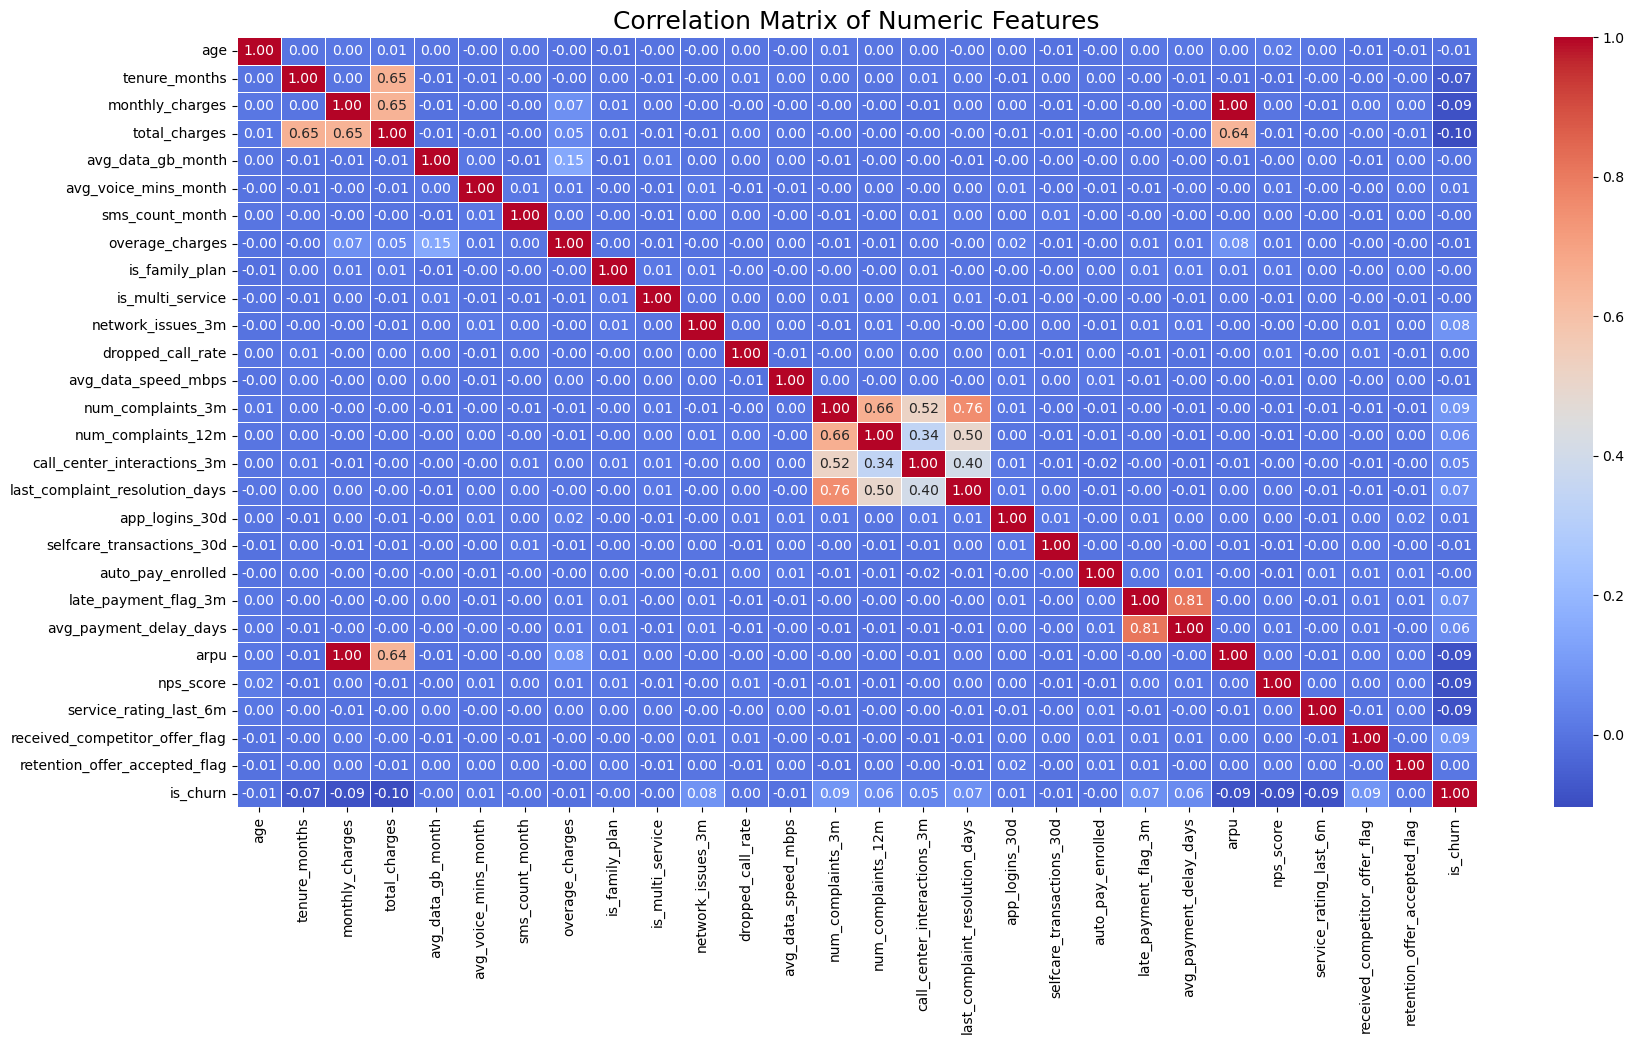

In [7]:
# -----------------------------------------------------------------------------
# CORRELATION ANALYSIS
# -----------------------------------------------------------------------------
corr_matrix = df[numerical_columns].corr()

plt.figure(figsize = (20,10))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f', linewidth = 0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize = 18)
plt.xticks(rotation = 90)
plt.show()

### **Business Interpretation: Correlation Matrix of Numeric Features**

---

#### **Correlation Analysis and Feature Insights**

The correlation matrix provides crucial insights into how customer behaviors and service usage relate to one another. Understanding these relationships is important in building an effective predictive model.
- A strong **positive correlation** (closer to +1) indicates a direct relationship.
- A strong **negative correlation** (closer to -1) indicates an inverse relationship.
- Values near zero indicate little to no relationship.

---

#### Key High Correlations (>0.6)

- **total_charges and tenure_months: +0.65 (strong positive)**
    - *Insight:* Customers who stay longer naturally accumulate higher total charges.
    - *Business Meaning:* This is expected and reflects customer lifetime value.

---

- **total_charges and monthly_charges: +0.65 (strong positive)**
    - *Insight:* Customers paying higher monthly fees tend to have higher total billing.
    - *Business Meaning:* Pricing plans directly impact revenue accumulation.

---

- **num_complaints_12m and num_complaints_3m: +0.66(strong positive)**
    - *Insight:* Customers who complained frequently in the short term also tend to have a history of complaints.
    - *Business Meaning:* Complaints are a persistent behavior, not random events.

---

- **last_complaint_resolution_days and num_complaints_3m: +0.76(very strong positive)**
    - *Insight:* Customers with more complaints tend to experience longer resolution time.
    - *Business Meaning:* High complaint volume may overload support systems or indicate complex issues.

---

- **avg_payment_delay_days and late_payment_flag_3m: +0.81(very strong positive)**
    - *Insight:* Customers flagged for late payments also shows higher payment delays.
    - *Business Meaning:* These variables capture the same financial behavior. Keep one or combine them to avoid redundancy.

---

- **arpu and monthly_charges: +1.00(perfect correlation)**
    - *Insight:* These are essentially the same variable.
    - *Business Meaning:* ARPU (Average Revenue Per User) is directly derived from monthly charges. Drop one feature (preferably keep monthly_charges for clarity) to avoid multicollinearity.

---

#### Multicollinearity Insights

- Strong correlations indicate redundant information.
- Key redundant groups:
    - arpu <-> monthly_charges, avg_payment_delay_days and late_payment_flag_3m.
- In machine learning models, this can cause instability.

---

#### Hidden Insights

- Complaint related variables are strongly interconnected, indicates *customer dissatisfaction is consistent and measurable.*
- Payment behavior variables are strongly linked, strong signal for *financial risk segmentation.*

---

#### Correlation with churn

- From the heatmap, no feature has a strong correlation with churn.
- Most values are around *±0.10 or lower.*
- This means churn is *not driven by a single factor,* but a *combination of behaviors.*

---

### **Feature Engineering from Business Perspective**
Below are the newly engineered features with clear business implications. These features leverage existing telecom data to provide deeper insights into customer behavior.

---

**1. Usage Behavior Features** <br>
**Definition:**
- high_data_consumption_flag - Top 25% data users.
- high_voice_usage_flag - Top 25% voice users.
- low_usage_flag - Bottom 25% in both data and voice.

**Business Insight:**
- Differentiates **high-value vs low engagement customers.**
- High-usage customers are *revenue-critical*, so their churn has a *high financial impact.*
- Low-usage customers may indicate *low-engagement or weak product fit*, making them more likely to churn silently.
- Enables *segment-specific retention strategies:*
    - High usage - premium offers, priority support.
    - Low usage - re-engagement campaigns.

---

**2. Tenure & Lifecycle Feature:** <br>
**Definition:** <br>
Categorizes customers based on tenure_months into:
- New (<= 12 months)
- Early (13-24 months)
- Mature (25-60 months)
- Loyal (> 60 months)

**Business Insight:** 
- Captures where a customer is in their **relationship journey with the company**.
- New customers are **high-risk** due to onboarding issues and lack of attachment.
- Loyal customers are **stable and high-value**, requiring retention focus.
- Helps design *lifecycle-based strategies:*
    - New - onboarding and engagement.
    - Mature/Loyal - loyalty rewards and upselling.

---

**3. Service Quality and Complaint Features** <br>
**Definition:** <br>
poor_complaint_handling - Customers with recent complaints and slow resolution (>2 days).

**Business Insight:**
- Directly measures **service failure + response inefficiency**.
- These customers are highly likely to churn due to **frustration and dissatisfaction**.
- Provides a **clear operational trigger:**
    - Prioritize these customers to **urgent resolution and escalation**.
 
---

**4. Contract and Commitment Risk Features** <br>
new_customer_high_risk - Customers with tenure <= 12 months and on prepaid plans.
**Business Insight:**
- Combines two major churn drivers:
    - Low commitment (prepaid)
    - Early lifecycle stage
- Identifies a **high-risk segment with weak retention barriers.**
- Ideal for targeted actions:
    - Push toward **postpaid or long-term plans**.
    - Provide **early incentives and onboarding support**.

---

**5. Customer Satisfaction and Loyalty features** <br>
**Definition:**
- nps_category - Detractor(<0), Passive(0 - 50), Promoter(> 50).
- low_service_rating - Bottom 25% service ratings.

**Business Insight:**
- Converts subjective feedback into **structured churn predictor**.
- Detractors are low ratings signal **dissatisfaction and high churn probability.**
- Enables proactive retention:
    - Identify unhappy customers early.
    - Launch **feedback-driven intervention campaigns.**
- Strongly aligns with **customer experience strategy.**

---

**6. Product/Plan Fit Features** <br>
**Definition:** <br>
plan_fit_score = 1 - (overage_charges/monthly_charges) bounded between 0 and 1.

**Business Insight:**
- Measures how well a customer's plan matches their usage.
- Low score - Customers frequently pays extra - **poor plan fit.**
- High score - Plan aligns well with usage - **better satisfaction**.
- Poor fit leads to:
    - Perceived overpricing.
    - Increased likelihood of switching providers.
- Enables:
    - Personalized plan recommendations.
    - Reduction in billing-related dissatisfaction.
---

In [8]:
# =============================================================================
# 3. FEATURE ENGINEERING
# =============================================================================
df_engg = df.copy()
print('\n--- Feature Engineering ---')
# -----------------------------------------------------------------------------
# A. Usage Behavior Features
# -----------------------------------------------------------------------------
print('\nCreating Usage Behavior Features')
# High data consumption flag:
# Heavy users are high-value customers; when they churn, the financial
# impact is significant. Their behavior often differ from low-usage customers.
df_engg['high_data_consumption_flag'] = (df_engg['avg_data_gb_month'] > 
                                        df_engg['avg_data_gb_month'].quantile(0.75)).astype(int)

# High voice call usage flag
df_engg['high_voice_usage_flag'] = (df_engg['avg_voice_mins_month'] >
                                   df_engg['avg_voice_mins_month'].quantile(0.75)).astype(int)

# Low usage customers (bottom 25% for both data and voice)
df_engg['low_usage_flag'] = ((df_engg['avg_data_gb_month']<df_engg['avg_data_gb_month'].quantile(0.25)) & 
                             (df_engg['avg_voice_mins_month'] < df_engg['avg_voice_mins_month'].quantile(0.25))).astype(int)
print('Created 3 Features.')
# -----------------------------------------------------------------------------
# B. Tenure & Lifecycle Features
# -----------------------------------------------------------------------------
print('\nCreating Tenure & Lifecycle Features')
# Customer lifecycle stage
def get_lifecycle_stage(tenure):
    if tenure <= 12:
        return 'new'
    elif tenure <= 24:
        return 'early'
    elif tenure <= 60:
        return 'mature'
    else:
        return 'loyal'

df_engg['lifecycle_stage'] = df_engg['tenure_months'].apply(get_lifecycle_stage)

print('Created 1 Feature.')

# -----------------------------------------------------------------------------
# C. Service Quality and Complaint Features
# -----------------------------------------------------------------------------
print('\nCreating Service Quality and Complaint Features')
# Poor Complaint Handelling (recent complaints + slow resolution)
df_engg['poor_complaint_handling'] = ((df_engg['num_complaints_3m'] > 0) &
                                     (df_engg['last_complaint_resolution_days'] > 2)).astype(int)
print('Created 1 feature.')
# -----------------------------------------------------------------------------
# D. Contract and Commitment Risk Features
# -----------------------------------------------------------------------------
print('\nCreating Contract and Commitment Risk Features')
# New Customer in risky plan_type (tenure <= 12 and prepaid customer)
df_engg['new_customer_high_risk'] = ((df_engg['tenure_months'] <= 12) &
                                    (df_engg['plan_type'] == 'Prepaid')).astype(int)
print('Created 1 Feature.')
# -----------------------------------------------------------------------------
# E. Customer Satisfaction and Loyalty features
# -----------------------------------------------------------------------------
print('\nCreating Customer Satisfaction and Loyalty Feature')
# NPS and service rating have negative correlation with churn

# NPS Category
def get_nps_category(score):
    if score < 0:
        return 'Detractor'
    elif score > 50:
        return 'Promoter'
    else:
        return 'Passive'

df_engg['nps_category'] = df_engg['nps_score'].apply(get_nps_category)

# Low Service Rating
df_engg['low_service_rating'] = (df_engg['service_rating_last_6m'] < 
                                df_engg['service_rating_last_6m'].quantile(0.25)).astype(int)
print('Created 2 Features.')
# -----------------------------------------------------------------------------
# F. Product/Plan Fit Features
# -----------------------------------------------------------------------------
print('\nCreating Product/Plan Fit Features')
# Plan Fit Score
df_engg['plan_fit_score'] = 1 - (df_engg['overage_charges'] / 
                                 (df_engg['monthly_charges'] + 1e-6))
df_engg['plan_fit_score'] = df_engg['plan_fit_score'].clip(0,1)
print('Created 1 Features.')

print('\n--- Feature Engineering Completed ---')


--- Feature Engineering ---

Creating Usage Behavior Features
Created 3 Features.

Creating Tenure & Lifecycle Features
Created 1 Feature.

Creating Service Quality and Complaint Features
Created 1 feature.

Creating Contract and Commitment Risk Features
Created 1 Feature.

Creating Customer Satisfaction and Loyalty Feature
Created 2 Features.

Creating Product/Plan Fit Features
Created 1 Features.

--- Feature Engineering Completed ---


### **Target Variable Check (Class Imbalance)**


--- Target Variable Distribution ---


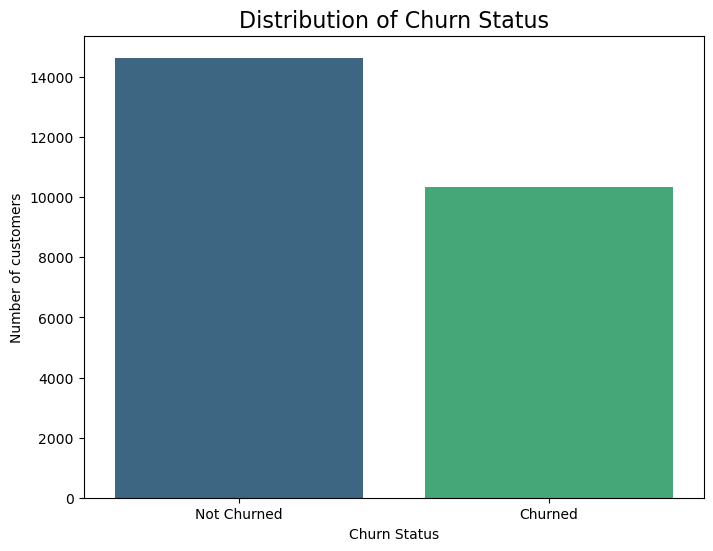


--- CHURN CLASS BALANCE ---
Total Customers: 25000
Not Churned(0):  14643 (58.57%)
Churned(1):      10357 (41.43%)


In [9]:
# -----------------------------------------------------------------------------
# Plot the Distribution of Target Variable ('is_churn')
# -----------------------------------------------------------------------------
print('\n--- Target Variable Distribution ---')
plt.figure(figsize = (8,6))
sns.countplot(x = 'is_churn', data=df, palette='viridis')
plt.title("Distribution of Churn Status", fontsize=16)
plt.xlabel("Churn Status")
plt.ylabel("Number of customers")
plt.xticks(ticks=[0,1], labels = ['Not Churned', 'Churned'])
plt.show()

# --- Calculate and print the balanced percentage ---
# Get the value counts:
churn_counts = df['is_churn'].value_counts()

# Calculate the percentage of each class:
total_customers = len(data)
churned_percentage = (churn_counts[1] / total_customers) * 100
not_churned_percentage = (churn_counts[0] / total_customers) * 100

print("\n--- CHURN CLASS BALANCE ---")
print(f"Total Customers: {total_customers}")
print(f"Not Churned(0):  {churn_counts[0]} ({not_churned_percentage:.2f}%)")
print(f"Churned(1):      {churn_counts[1]} ({churned_percentage:.2f}%)")

### **Business Interpretation: Class Balance**

The bar chart illustrates the distribution of our target variable, *Churn status (is_churn)*, highlighting the proportion of customers who have churned versus those who have been retained.
- *Not Churned (Retained):* 14463 customers (**58.57%**)
- *Churned:* 10357 customers (**41.43%**)
-  *Total Customers:* 25000

---

#### Business Perspective

This dataset shows a **moderate class imbalance (60:40)**, where retained customers outnumber churned customers.

- **Manageable Imbalance:** <br>
      The imbalance is not extreme (roughly 60:40), meaning the model will still have sufficient examples of churned customers to learn meaningful patterns. However there is a slight risk that the model may become **biased toward predicting retention (majority class).**

- **Business Implication:** <br>
    Since churned customers represent **critical revenue-loss segment**, correctly identifying them is more important than optimizing overall accuracy. Missing churned customers (false negatives) could directly impact revenue.


---

## **Data Preparation and Splitting**

Before building Machine Learning Model, we must:

- **Define our features (X)** clearly-these are the 41 predictor variables.
- **Set the target variable (y)**-in our case, **is_churn**.
- **Split the data into training and testing sets** to ensure we can evaluate the model's performance on unseen data.

We use an **80% - 20% train-test split**, a standard practice that provides enough data for model to learn complex patterns while reserving a robust set for evaluation.

The dataset is **fairly balanced (58:42 ratio)**, with a majority of non-churned customers. This level of imbalance is **not severe**, but still important to handle carefully during modeling. We will apply the **stratify parameter** in our split. This is a crucial best practice that ensures the proportion of churned vs non-churned is identical in both the training and testing sets. This guarantees that our model's evaluation is based on a truly representative sample of the data, leading to a more reliable assessment of its performance.

During the feature selection stage, the variable **'arpu' (Average Revenue Per User)** was removed from the dataset because due to its **perfect correlation (1.0)** with the feature **'monthly_charges'**. A correlation of 1 indicates a *perfect linear relationship*, meaning both features carry *identical information*. Including both variables would introduce *multicollinearity*, which can negatively impact model performance. **tenure_months** also removed as it has already been transformed into more meaningful derived feature *lifecycle_stage*.

---

--- Data Preprocessing ---
Data Split Completed:
X_train Shape: (20000, 41)
X_test Shape:  (5000, 41)
y_train Shape: (20000,)
y_test Shape:  (5000,)


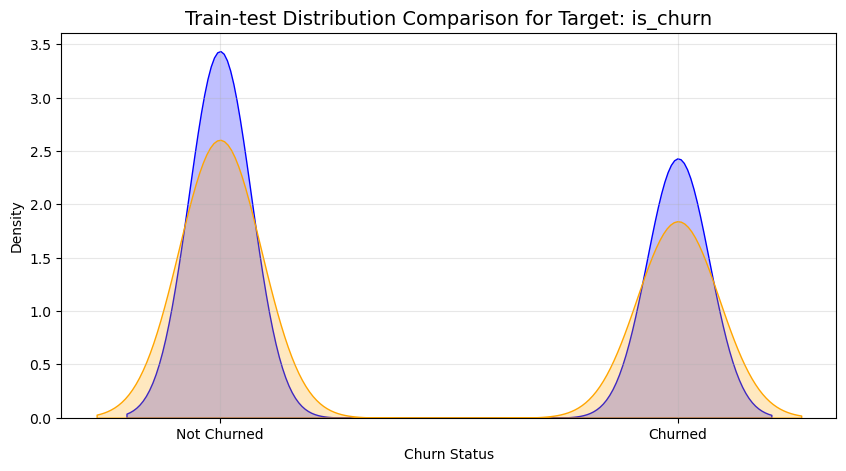


Distribution of Training Sets's Target Variable:
Churned Percentage / Non Churned Percentage: 41.43% / 58.57%

Distribution of Testing Set's Target Variable:
Churned Percentage / Non Churned Percentage: 41.42% / 58.58%


In [10]:
# ============================================================================
# 4. DATA PREPROCESSING
# ============================================================================
print('--- Data Preprocessing ---')
# Drop 'arpu' and 'tenure_months' as 'arpu' has perfect correlation (1.0) with 'monthly charges' which introduce multicollinearity.
# And 'tenure_months has already been transformed into more meaningful derived feature.'
model_data = df_engg.drop(columns = ['arpu', 'tenure_months']) 
target = 'is_churn'

# Create feature matrix X and target vector y
# We drop the target from X and the non-feature categorical columns
X = model_data.drop(columns = [target])
y = model_data[target]

# Split the data into training and testing sets (80% train, 20% test)
# The 'stratify=y' argument is critical for maintaining the same class distribution
# in both the training and testing sets, which is essential for imbalanced dataset.
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.20,
                                                stratify=y, random_state=42)

# Confirm the shapes of the split dataframes:
print("Data Split Completed:")
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape:  {y_test.shape}")


#--- Plotting the Distribution of Target Variable ---
plt.figure(figsize=(10,5))
sns.kdeplot(y_train, color = 'blue', label='Train', fill=True)
sns.kdeplot(y_test, color='orange', label='Test', fill=True)
plt.title('Train-test Distribution Comparison for Target: is_churn', fontsize=14)
plt.xlabel('Churn Status')
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.legend
plt.xticks(ticks=[0,1], labels=['Not Churned','Churned'])
plt.show()



# Calculate the percentage of each class:
churn_counts_train = y_train.value_counts()
churn_counts_test = y_test.value_counts()

total_customers_train = len(X_train)
total_customers_test = len(X_test)

churned_percentage_train = (churn_counts_train[1] / total_customers_train) * 100
not_churned_percentage_train = (churn_counts_train[0] / total_customers_train) * 100


churned_percentage_test = (churn_counts_test[1] / total_customers_test)*100
non_churned_percentage = (churn_counts_test[0] / total_customers_test)*100


print("\nDistribution of Training Sets's Target Variable:")
print(f'Churned Percentage / Non Churned Percentage: {churned_percentage_train}% / {not_churned_percentage_train}%')

print("\nDistribution of Testing Set's Target Variable:")
print(f'Churned Percentage / Non Churned Percentage: {churned_percentage_test}% / {non_churned_percentage}%')

#### **Visual Validation of the Split**

**Highly Similar Distributions** <br>
The distributions of the **Churned** variable in both the training (blue) and testing (orange) sets display a nearly identical proportions of 0s (non-churners) and 1s (churners). This visually confirms that both subsets are perfect representations of the original dataset's class balance.

**Model Reliability**
This successful split was achieved by using the **stratify=y** parameter in the 'train_test_split'.<br>
This prevents the model from being biased and ensures the performance metrics we calculated later will be meaningful and reliable.

---

## **Encoding**

Encoding is crucial because machine learning models can only process numerical data. The process of encoding converts text-based labels into a numerical format that the algorithm can use to build its decision rules. <br>
By fitting the encoder on the training data only and then using that fitted encoder to transform the test data, we simulate a real-world scenario where the model learns only from the data it was trained on.

---

### Encoding the Categorical Features

We'll use **One-Hot Encoding** for the following categorical features:

- gender
- region_circle
- connection_type
- plan_type
- contract_type
- base_plan_category
- segment_value

**One-Hot Encoding** creates a new binary column for each unique category. This approach prevents the model from assuming an incorrect ordinal relationship between categories (e.g., wrongly treating a '2-year' contract as inherently 'better' than a 'month-to-month' one). The parameter *handle_unknown='ignore'* was used to safely handle unseen categories in the test data.

---

In [11]:
#--- Feature Encoding: OneHotEncoder ---
print('--- Categorical Variable Encoding ---')
# Identify categorical and numerical features
numerical_columns = X_train.select_dtypes(include=['int64','float64']).columns
categorical_columns = X_train.select_dtypes(include=['object']).columns

# Initialize the OneHotEncoder
# handle_unknown = 'ignore' ensures code doesn't break if a new category appears in the test set.
encoder_fe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit the encoder on the training data only:
encoder_fe.fit(X_train[categorical_columns])

# Transform both training and testing data using the fitted encoder
X_train_encoded = encoder_fe.transform(X_train[categorical_columns])
X_test_encoded = encoder_fe.transform(X_test[categorical_columns])

# Create dataframes with the encoded features
# Get the new column names created by the encoder
encoded_feature_names = encoder_fe.get_feature_names_out(categorical_columns)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

# Combine encoded categorical and original numerical features
X_train_en = pd.concat([X_train[numerical_columns],X_train_encoded_df], axis=1)
X_test_en = pd.concat([X_test[numerical_columns], X_test_encoded_df], axis=1)

print(f"Shape of Final X_train: {X_train.shape}")
print(f"\nFinal Column List:")
print(X_train_en.columns)

--- Categorical Variable Encoding ---
Shape of Final X_train: (20000, 41)

Final Column List:
Index(['age', 'monthly_charges', 'total_charges', 'avg_data_gb_month',
       'avg_voice_mins_month', 'sms_count_month', 'overage_charges',
       'is_family_plan', 'is_multi_service', 'network_issues_3m',
       'dropped_call_rate', 'avg_data_speed_mbps', 'num_complaints_3m',
       'num_complaints_12m', 'call_center_interactions_3m',
       'last_complaint_resolution_days', 'app_logins_30d',
       'selfcare_transactions_30d', 'auto_pay_enrolled',
       'late_payment_flag_3m', 'avg_payment_delay_days', 'nps_score',
       'service_rating_last_6m', 'received_competitor_offer_flag',
       'retention_offer_accepted_flag', 'high_data_consumption_flag',
       'high_voice_usage_flag', 'low_usage_flag', 'poor_complaint_handling',
       'new_customer_high_risk', 'low_service_rating', 'plan_fit_score',
       'gender_Female', 'gender_Male', 'gender_Other', 'region_circle_East',
       'region_cir

## **Model Building**

---

### **Model 1: Baseline Logistic Regression**


--- Model Building & Evaluation ---

--- Model 1: Logistic Regression(Baseline) Including Engineered Features ---

ROC-AUC-Score for Baseline Logistic Regression Model: 0.6611

Classification Report of Baseline Logistic Regression Model (FE)
              precision    recall  f1-score   support

           0       0.68      0.64      0.66      2929
           1       0.54      0.58      0.56      2071

    accuracy                           0.62      5000
   macro avg       0.61      0.61      0.61      5000
weighted avg       0.62      0.62      0.62      5000


Baseline Model Confusion Matrix (FE)


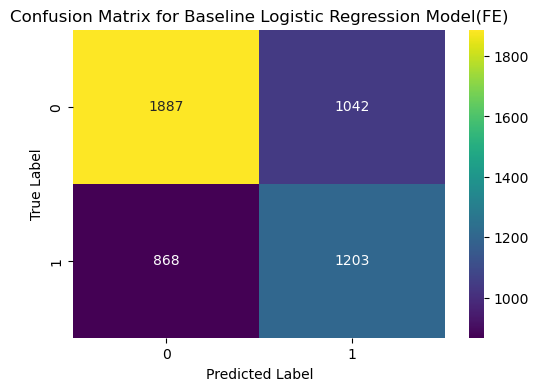


Check for Overfitting:
Recall-Score for Training Data: 0.6021
Recall-Score for Test Data:     0.5809
Recall-Score Gap:  0.0212

Train AUC:  0.6649
Test AUC:    0.6611
AUC Gap:     0.0037


In [12]:
# ============================================================================
# 5. MODEL BUILDING & EVALUATION
# ============================================================================
print('\n--- Model Building & Evaluation ---')
# ----------------------------------------------------------------------------
# Model 1: Logistic Regression Model (Baseline)
# ----------------------------------------------------------------------------
print('\n--- Model 1: Logistic Regression(Baseline) Including Engineered Features ---')

# Scale features for Logistic regression:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_en)
X_test_scaled = scaler.transform(X_test_en)
# RobustScaler is chosen over StandardScaler because our EDA identified 
# significant outliers in some features (e.g., monthly_charges: 1358 outliers,
# last_complaint_resolution_days: 5979 outliers).
# RobustScaler uses median and IQR instead of mean and std, making it resistant
# to these extreme values without requiring outlier removal.

# Baseline model
baseline_lr = LogisticRegression(class_weight = 'balanced')
baseline_lr.fit(X_train_scaled, y_train)

# Prediction
y_pred_baseline = baseline_lr.predict(X_test_scaled)
y_pred_proba_baseline = baseline_lr.predict_proba(X_test_scaled)[:,1]

# Model Evaluation
auc_baseline = roc_auc_score(y_test, y_pred_proba_baseline)
print(f"\nROC-AUC-Score for Baseline Logistic Regression Model: {auc_baseline:.4f}")

print('\nClassification Report of Baseline Logistic Regression Model (FE)')
print(classification_report(y_test, y_pred_baseline))

print('\nBaseline Model Confusion Matrix (FE)')
confusion_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize = (6,4))
sns.heatmap(confusion_baseline, annot=True, cmap='viridis', fmt='d')
plt.title('Confusion Matrix for Baseline Logistic Regression Model(FE)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# Overfitting Check
print('\nCheck for Overfitting:')
# Train Predictions
y_pred_baseline_train = baseline_lr.predict(X_train_scaled)
y_pred_proba_train = baseline_lr.predict_proba(X_train_scaled)[:,1]

# Recall
train_recall_baseline = recall_score(y_train, y_pred_baseline_train)
test_recall_baseline = recall_score(y_test,y_pred_baseline)

#AUC
train_auc = roc_auc_score(y_train, y_pred_proba_train)

print(f'Recall-Score for Training Data: {train_recall_baseline:.4f}')
print(f'Recall-Score for Test Data:     {test_recall_baseline:.4f}')
print(f'Recall-Score Gap:  {(train_recall_baseline - test_recall_baseline):.4f}')

print(f'\nTrain AUC:  {train_auc:.4f}')
print(f'Test AUC:    {auc_baseline:.4f}')
print(f'AUC Gap:     {(train_auc - auc_baseline):.4f}')

## **Business Interpretation of the Baseline Model Results**

| **Metric** | **Class 0 (Non-Churn)** | **Class 1 (Churn)** | **Interpretation** |
|------------|-------------------------|---------------------|--------------------|
| **Precision** | 0.68 | 0.54 | Out of all customers predicted to churn, only 54% actually churned. This means there are still a significant number of false positives (customers incorrectly flagged as churners). |
| **Recall** | 0.64 | 0.58 | Out of all customers who actually churned (class 1), the model correctly identified 58%. This is better than random guess but still misses 42% of customers who will churn. |
| **F1-Score** | 0.66 | 0.56 | The harmonic mean of precision and recall is 0.56. The model is reasonably consistent but not strong enough for high-stakes decisions. |
| **Accuracy** | 0.62 |  | Overall accuracy is 62% which is better than random guess (50%), indicating the model has learned some useful patterns.

--- 

### **Overall Business Takeaway**

The current **baseline model is not viable for business use**.

**For Retention Strategies** <br>
If ConnectTel were to use this model, they would only correctly identify 58% of the customers they need to target with retention offers (**not enough Recall for 'churned'**).

---

### **Model 2: Tuned Logistic Regression (Hyperparameter Tuning with Grid Search and K-Fold)**

The goal of subsequent models is to move past the suboptimal performance of the baseline model and find a model that ConnectTel can reliably use to guide its retention strategy.

**Business Usefulness:** Tuning prevents the model from being too simple (*underfitting*, which causes us to miss churners) or too complex (*overfitting*, performing well on training data and poorly on testing data). An optimized model provides a better balance, leading to higher *Recall*.

---


--- Model 2: Logistic Regression (Tuned) Including Engineered Features ---

-> Tuning Logistic Regression...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Parameters for Logistic regression Model: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Recall-Score: 0.6288

ROC-AUC Score for Tuned Logistic Regression: 0.6595

Classification Report of Tuned Logistic Regression Model (FE)
              precision    recall  f1-score   support

           0       0.69      0.62      0.65      2929
           1       0.53      0.61      0.57      2071

    accuracy                           0.61      5000
   macro avg       0.61      0.61      0.61      5000
weighted avg       0.62      0.61      0.62      5000


Tuned Logistic regression Confusion Matrix(FE)


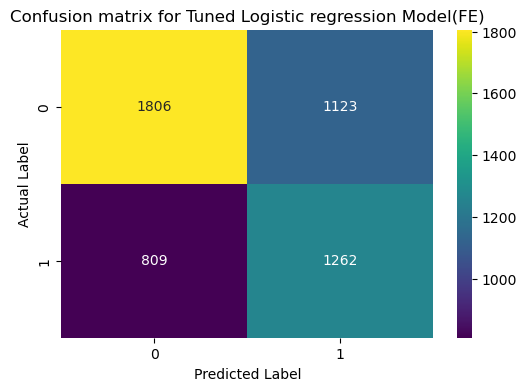


Check for Overfitting
Recall-Score for Training Data: 0.6233
Recall_score for Testing Data:  0.6094
Recall-Score Gap: 0.0140

Train AUC:   0.6584
Test AUC:    0.6595
AUC Gap:     -0.0011


In [13]:
# ----------------------------------------------------------------------------
# Model 2: Tuned Logistic Regression Model
# ----------------------------------------------------------------------------

# Cross-Validation Strategy
cv_strategy = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

print('\n--- Model 2: Logistic Regression (Tuned) Including Engineered Features ---')
# Tuning
print('\n-> Tuning Logistic Regression...')
param_grid_lr = {
    'C': [0.001,0.01, 0.1, 1],
    'penalty': ['l1','l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced']
}

grid_search_lr = GridSearchCV(
    LogisticRegression(max_iter = 10000),
    param_grid_lr,
    cv = cv_strategy,
    scoring = 'recall',
    n_jobs = 1,
    verbose = 1
)
grid_search_lr.fit(X_train_scaled, y_train)

print(f'\nBest Parameters for Logistic regression Model: {grid_search_lr.best_params_}')
print(f'Best Cross-Validation Recall-Score: {grid_search_lr.best_score_:.4f}')

# Prediction
tuned_lr = grid_search_lr.best_estimator_
y_pred_lr_tuned = tuned_lr.predict(X_test_scaled)
y_pred_proba_tuned_lr = tuned_lr.predict_proba(X_test_scaled)[:,1]

# Model Evaluation
auc_lr_tuned = roc_auc_score(y_test, y_pred_proba_tuned_lr)
print(f'\nROC-AUC Score for Tuned Logistic Regression: {auc_lr_tuned:.4f}')

# Classification Report
print('\nClassification Report of Tuned Logistic Regression Model (FE)')
print(classification_report(y_test, y_pred_lr_tuned))

# Confusion Matrix:
print('\nTuned Logistic regression Confusion Matrix(FE)')
confusion_lr_tuned = confusion_matrix(y_test, y_pred_lr_tuned)
plt.figure(figsize= (6,4))
sns.heatmap(confusion_lr_tuned, annot=True, cmap='viridis', fmt='d')
plt.title('Confusion matrix for Tuned Logistic regression Model(FE)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()


# Overfitting Check
print('\nCheck for Overfitting')
# Train prediction
y_pred_tuned_lr_train = tuned_lr.predict(X_train_scaled)
y_pred_proba_tuned_lr_train = tuned_lr.predict_proba(X_train_scaled)[:,1]

# Recall
train_recall_tuned_lr = recall_score(y_train, y_pred_tuned_lr_train)
test_recall_tuned_lr = recall_score(y_test, y_pred_lr_tuned)

# AUC
train_auc = roc_auc_score(y_train, y_pred_proba_tuned_lr_train)
test_auc = auc_lr_tuned

print(f'Recall-Score for Training Data: {train_recall_tuned_lr:.4f}')
print(f'Recall_score for Testing Data:  {test_recall_tuned_lr:.4f}')
print(f'Recall-Score Gap: {(train_recall_tuned_lr - test_recall_tuned_lr):.4f}')

print(f'\nTrain AUC:   {train_auc:.4f}')
print(f'Test AUC:    {test_auc:.4f}')
print(f'AUC Gap:     {(train_auc - test_auc):.4f}')

---

### **Model 3: Tuned Random Forest Model (Hyperparameter Tuning with Grid Search  and K-Fold) Including Engineered Features**

The goal of this model is to improve churn prediction performance by combining *Feature Engineering* (to create meaningful business-driven features), *Hyperparameter Tuning* to optimize model performance and K-Fold cross-validation to ensure generalization.

---


--- Model 3: Random Forest Classifier(Tuned) Including Engineered Features ---
Tuning Random Forest Classifier...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Tuning Completed.

Best Parameters for Random Forest Model: {'class_weight': 'balanced', 'max_depth': 4, 'max_features': 'log2', 'min_samples_leaf': 20, 'n_estimators': 300}
Best CrossValidation Recall-Score: 0.5888

Model Evaluation Metrics:

ROC-AUC Score for Tuned Random Forest : 0.6378

Classification Report of Tuned Random Forest Model Including Engineered Features
              precision    recall  f1-score   support

           0       0.67      0.63      0.65      2929
           1       0.52      0.56      0.54      2071

    accuracy                           0.60      5000
   macro avg       0.59      0.60      0.59      5000
weighted avg       0.61      0.60      0.60      5000


Random Forest(Tuned) Confusion Matrix


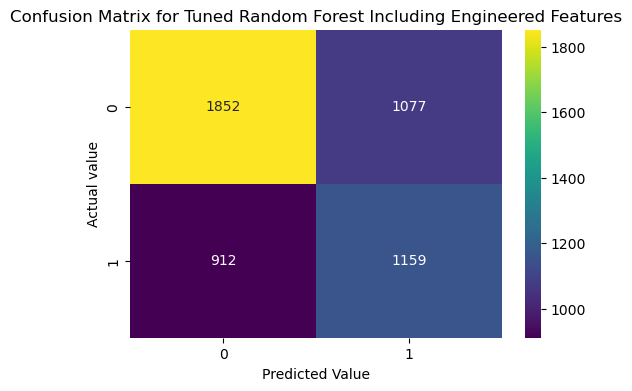


Check for Overfitting
Train Recall: 0.5839
Test Recall:  0.5596
Recall Gap:   0.0242

Train AUC:   0.6534
Test AUC:     0.6378
AUC Gap:      0.0156


In [14]:
# -----------------------------------------------------------------------------
# Model 3: Random Forest Classifier (Tuned) Including Engineered Features
# -----------------------------------------------------------------------------
print('\n--- Model 3: Random Forest Classifier(Tuned) Including Engineered Features ---')
print('Tuning Random Forest Classifier...')

param_grid_rf_engg = {
    'n_estimators': [300],
    'max_depth':[4,6,8],
    'min_samples_leaf':[8,10,20],
    'max_features':['sqrt','log2'],
    'class_weight':['balanced']
}

grid_search_rf_engg = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf_engg,
    cv = cv_strategy,
    scoring = 'recall',
    n_jobs = 1,
    verbose = 1
)
grid_search_rf_engg.fit(X_train_en, y_train)

print('Tuning Completed.')
print(f'\nBest Parameters for Random Forest Model: {grid_search_rf_engg.best_params_}')
print(f'Best CrossValidation Recall-Score: {grid_search_rf_engg.best_score_:.4f}')

# Prediction
tuned_rf_engg = grid_search_rf_engg.best_estimator_
y_pred_rf_engg = tuned_rf_engg.predict(X_test_en)
y_pred_proba_rf_engg = tuned_rf_engg.predict_proba(X_test_en)[:,1]

# Model Evaluation
print('\nModel Evaluation Metrics:')
auc_tuned_rf_engg = roc_auc_score(y_test, y_pred_proba_rf_engg)
print(f'\nROC-AUC Score for Tuned Random Forest : {auc_tuned_rf_engg:.4f}')

# Classification Report
print('\nClassification Report of Tuned Random Forest Model Including Engineered Features')
print(classification_report(y_test, y_pred_rf_engg))

# Confusion Matrix
print('\nRandom Forest(Tuned) Confusion Matrix')
confusion_rf_engg = confusion_matrix(y_test, y_pred_rf_engg)
plt.figure(figsize = (6,4))
sns.heatmap(confusion_rf_engg, annot=True, cmap='viridis', fmt='d')
plt.title('Confusion Matrix for Tuned Random Forest Including Engineered Features')
plt.xlabel('Predicted Value')
plt.ylabel('Actual value')
plt.show()

# Overfitting Check
print('\nCheck for Overfitting')
# train prediction
y_pred_rf_train_engg = tuned_rf_engg.predict(X_train_en)
y_pred_proba_rf_train_engg = tuned_rf_engg.predict_proba(X_train_en)[:,1]

# recall
tuned_rf_train_recall_engg = recall_score(y_train, y_pred_rf_train_engg)
tuned_rf_test_recall_engg = recall_score(y_test, y_pred_rf_engg)

# AUC
train_auc = roc_auc_score(y_train, y_pred_proba_rf_train_engg)
test_auc = auc_tuned_rf_engg

print(f'Train Recall: {tuned_rf_train_recall_engg:.4f}')
print(f'Test Recall:  {tuned_rf_test_recall_engg:.4f}')
print(f'Recall Gap:   {(tuned_rf_train_recall_engg - tuned_rf_test_recall_engg):.4f}')
print(f'\nTrain AUC:   {train_auc:.4f}')
print(f'Test AUC:     {test_auc:.4f}')
print(f'AUC Gap:      {(train_auc - test_auc):.4f}')

---

### **Model 4: Tuned Random Forest Model (Hyperparameter Tuning with Grid Search and K-Fold) Excluding Engineered Features**

The objective of this model was to evaluate the performance of a *Random Forest classifier using only the original features*, without introducing any engineered variables, while still leveraging *Hyperparameter Tuning*, *K-Fold Cross-Validation*. This helps in understanding whether feature engineering actually adds value or not. Unlike linear models, *Random Forest* can *naturally capture non-linear relationships and feature interactions*, reducing the need for manual feature engineering.

---


--- Model 4: Random Forest Classifier (Tuned) Excluding Engineered Features) ---
Tuning Random Forest Classifier...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Tuning Completed

Best Parameters for Random Forest Model: {'class_weight': 'balanced', 'max_depth': 4, 'max_features': 'log2', 'min_samples_leaf': 10, 'n_estimators': 300}

Best Cross-Validationb Recall-Score: 0.6568

Model Evaluation Metrics:

ROC-AUC Score for Tuned Random Forest: 0.6393

Classification Report of Tuned Random Forest Model Excluding Enginnered Features
              precision    recall  f1-score   support

           0       0.68      0.55      0.61      2929
           1       0.50      0.64      0.56      2071

    accuracy                           0.59      5000
   macro avg       0.59      0.59      0.59      5000
weighted avg       0.61      0.59      0.59      5000


Random Forest (Tuned) Confusion Matrix (No feature Engineering)


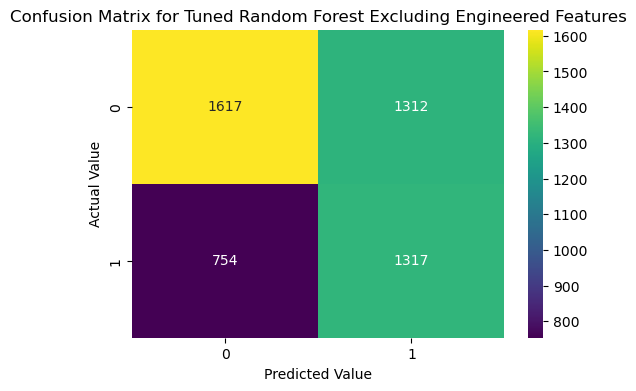


Check for Overfitting
Train Recall: 0.6603
Test Recall:  0.6359
Recall Gap:   0.0243

Train AUC:   0.6564
Test AUC:     0.6393
AUC Gap:      0.0171


In [15]:
# -----------------------------------------------------------------------------
# Model 4: Random Forest Classifier (Tuned) Excluding Engineered features
# -----------------------------------------------------------------------------

# -----------------------------------------------------------------------------
# Data Preprocessing:
model_data = df.drop(columns = ['arpu'])
target = 'is_churn'

# Create feature matrix X and target vector y
# We drop the target from X and the non-feature categorical columns
X = model_data.drop(columns = [target])
y = model_data[target]

# Split the data into training and testing sets (80% train, 20% test)
# The 'stratify=y' argument is critical for maintaining the same class distribution
# in both the training and testing sets, which is essential for imbalanced dataset.
X_train_no_fe,X_test_no_fe,y_train_no_fe,y_test_no_fe = train_test_split(X, y, test_size=0.20,
                                                stratify=y, random_state=42)


#--- Feature Encoding: OneHotEncoder ---

# Identify categorical and numerical features
numerical_columns = X_train_no_fe.select_dtypes(include=['int64','float64']).columns
categorical_columns = X_train_no_fe.select_dtypes(include=['object']).columns

# Initialize the OneHotEncoder
# handle_unknown = 'ignore' ensures code doesn't break if a new category appears in the test set.
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit the encoder on the training data only:
encoder.fit(X_train_no_fe[categorical_columns])

# Transform both training and testing data using the fitted encoder
X_train_encoded = encoder.transform(X_train_no_fe[categorical_columns])
X_test_encoded = encoder.transform(X_test_no_fe[categorical_columns])

# Create dataframes with the encoded features
# Get the new column names created by the encoder
encoded_feature_names = encoder.get_feature_names_out(categorical_columns)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train_no_fe.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test_no_fe.index)

# Combine encoded categorical and original numerical features
X_train_en_no_fe = pd.concat([X_train_no_fe[numerical_columns],X_train_encoded_df], axis=1)
X_test_en_no_fe = pd.concat([X_test_no_fe[numerical_columns], X_test_encoded_df], axis=1)


# -----------------------------------------------------------------------------

print('\n--- Model 4: Random Forest Classifier (Tuned) Excluding Engineered Features) ---')
print('Tuning Random Forest Classifier...')

param_grid_rf = {
    'n_estimators':[300],
    'max_depth':[4,6,8],
    'min_samples_leaf':[8,10,20],
    'max_features':['sqrt','log2'],
    'class_weight':['balanced']
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state = 42),
    param_grid_rf,
    cv = cv_strategy,
    scoring = 'recall',
    n_jobs = 1,
    verbose = 1
)
grid_search_rf.fit(X_train_en_no_fe, y_train_no_fe)
print('Tuning Completed')

print(f'\nBest Parameters for Random Forest Model: {grid_search_rf.best_params_}')
print(f'\nBest Cross-Validationb Recall-Score: {grid_search_rf.best_score_:.4f}')

# Prediction
tuned_rf = grid_search_rf.best_estimator_
y_pred_rf = tuned_rf.predict(X_test_en_no_fe)
y_pred_proba_rf = tuned_rf.predict_proba(X_test_en_no_fe)[:,1]

# Model Evaluation
print('\nModel Evaluation Metrics:')
auc_tuned_rf = roc_auc_score(y_test_no_fe, y_pred_proba_rf)
print(f'\nROC-AUC Score for Tuned Random Forest: {auc_tuned_rf:.4f}')

# Classification Report
print('\nClassification Report of Tuned Random Forest Model Excluding Enginnered Features')
print(classification_report(y_test_no_fe, y_pred_rf))

# Confusion Matrix
print('\nRandom Forest (Tuned) Confusion Matrix (No feature Engineering)')
confusion_rf = confusion_matrix(y_test_no_fe, y_pred_rf)
plt.figure(figsize = (6,4))
sns.heatmap(confusion_rf, annot = True, cmap = 'viridis', fmt='d')
plt.title('Confusion Matrix for Tuned Random Forest Excluding Engineered Features')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()

# Overfitting Check:
print('\nCheck for Overfitting')
# train_prediction
y_pred_rf_train = tuned_rf.predict(X_train_en_no_fe)
y_pred_proba_rf_train = tuned_rf.predict_proba(X_train_en_no_fe)[:,1]

# Recall
tuned_rf_train_recall = recall_score(y_train_no_fe, y_pred_rf_train)
tuned_rf_test_recall = recall_score(y_test_no_fe, y_pred_rf)

# AUC
train_auc = roc_auc_score(y_train_no_fe, y_pred_proba_rf_train)
test_auc = auc_tuned_rf

print(f'Train Recall: {tuned_rf_train_recall:.4f}')
print(f'Test Recall:  {tuned_rf_test_recall:.4f}')
print(f'Recall Gap:   {(tuned_rf_train_recall - tuned_rf_test_recall):.4f}')
print(f'\nTrain AUC:   {train_auc:.4f}')
print(f'Test AUC:     {test_auc:.4f}')
print(f'AUC Gap:      {(train_auc - test_auc):.4f}')

**Comparison between Random Forest with FE and Without FE**: <br>
Feature engineering reduced performance because Random Forest already captures non-linear relationships and feature interactions. The engineered features introduced redundancy and noise due to assumptions. This diluted the importance of key continuous variables like tenure and NPS score, leading to weaker splits and increased false negatives. As a result, recall dropped, making the model less effective for churn prediction.

---

### **Model 5: XG Boost Classifier (Tuned)**

XG Boost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm based on gradient boosting. Trees are built sequentially, with each new tree focuses on correcting previous errors. This makes XG Boost more powerful, more sensitive to important patterns, better at handling tabular data.


--- Model 5: XG Boost Model (Tuned) (No FE)----
-> Tuning XG Boost Classifier...
Fitting 5 folds for each of 512 candidates, totalling 2560 fits

Tuning Completed

Best Parameters for XG Boost Model: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 100, 'reg_alpha': 0.5, 'reg_lambda': 2, 'scale_pos_weight': 1.4137098720733767, 'subsample': 0.9}
Best Cross Validation Recall-Score:    0.6074

Model Evaluation Metrics:

ROC-AUC Score for Tuned XG Boost Model: 0.6551

Classification Report for Tuned XG Boost Model (No FE)
              precision    recall  f1-score   support

           0       0.68      0.63      0.65      2929
           1       0.52      0.58      0.55      2071

    accuracy                           0.61      5000
   macro avg       0.60      0.60      0.60      5000
weighted avg       0.61      0.61      0.61      5000


XG Boost (Tuned) Confusion Matrix


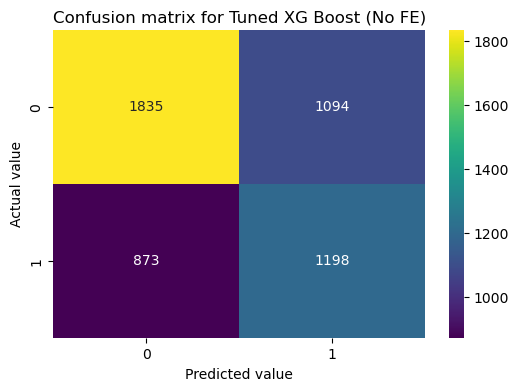


Check for Overfitting
Train Recall: 0.6422
Test Recall:  0.5785
Recall Gap:   0.0637

Train AUC:    0.7020
Test AUC:     0.6551
AUC Gap:      0.0468


In [16]:
# -----------------------------------------------------------------------------
# Model 5: XG Boost Classifier (Tuned) (No FE)
# -----------------------------------------------------------------------------
print('\n--- Model 5: XG Boost Model (Tuned) (No FE)----')
print('-> Tuning XG Boost Classifier...')

scale_pos_weight = len(y_train_no_fe[y_train_no_fe==0]) / len(y_train_no_fe[y_train_no_fe==1])
param_grid_xg = {
    'learning_rate':[0.05, 0.1],
    'n_estimators':[100,200],
    'max_depth':[4,6],
    'min_child_weight':[1,3],
    'subsample':[0.8,0.9],
    'colsample_bytree':[0.8,0.9],
    'reg_alpha':[0,0.5],
    'reg_lambda':[1,2],
    'gamma':[0,0.1],
    'scale_pos_weight':[scale_pos_weight]
}

grid_search_xg = GridSearchCV(
    XGBClassifier(objective = 'binary:logistic',
                  random_state = 42,
                  eval_metric = 'logloss'),
    param_grid_xg,
    cv = cv_strategy,
    scoring = 'recall',
    n_jobs = 1,
    verbose = 1
)
grid_search_xg.fit(X_train_en_no_fe, y_train_no_fe)
print('\nTuning Completed')

print(f'\nBest Parameters for XG Boost Model: {grid_search_xg.best_params_}')
print(f'Best Cross Validation Recall-Score:    {grid_search_xg.best_score_:.4f}')

# Prediction:
tuned_xg = grid_search_xg.best_estimator_
y_pred_xg = tuned_xg.predict(X_test_en_no_fe)
y_pred_proba_xg = tuned_xg.predict_proba(X_test_en_no_fe)[:,1]

# Model Evaluation
print('\nModel Evaluation Metrics:')
auc_tuned_xg = roc_auc_score(y_test_no_fe, y_pred_proba_xg)
print(f'\nROC-AUC Score for Tuned XG Boost Model: {auc_tuned_xg:.4f}')

# Calssification Report
print('\nClassification Report for Tuned XG Boost Model (No FE)')
print(classification_report(y_test_no_fe, y_pred_xg))

# Confusion Matrix
print('\nXG Boost (Tuned) Confusion Matrix')
confusion_xg = confusion_matrix(y_test_no_fe, y_pred_xg)
plt.figure(figsize = (6,4))
sns.heatmap(confusion_xg, annot=True, cmap='viridis', fmt='d')
plt.title('Confusion matrix for Tuned XG Boost (No FE)')
plt.xlabel('Predicted value')
plt.ylabel('Actual value')
plt.show()

# Overfitting Check
print('\nCheck for Overfitting')
# Train set prediction
y_pred_xg_train = tuned_xg.predict(X_train_en_no_fe)
y_pred_proba_xg_train = tuned_xg.predict_proba(X_train_en_no_fe)[:,1]

# Recall
tuned_xg_train_recall = recall_score(y_train_no_fe, y_pred_xg_train)
tuned_xg_test_recall = recall_score(y_test_no_fe, y_pred_xg)

# AUC
train_auc = roc_auc_score(y_train_no_fe, y_pred_proba_xg_train)
test_auc = auc_tuned_xg

print(f'Train Recall: {tuned_xg_train_recall:.4f}')
print(f'Test Recall:  {tuned_xg_test_recall:.4f}')
print(f'Recall Gap:   {(tuned_xg_train_recall - tuned_xg_test_recall):.4f}')
print(f'\nTrain AUC:    {train_auc:.4f}')
print(f'Test AUC:     {test_auc:.4f}')
print(f'AUC Gap:      {(train_auc - test_auc):.4f}')

### **Model Comparison**

In [17]:
# Define the metrics based on the previous model reports

precision_baseline = round(precision_score(y_test, y_pred_baseline),2)
precision_lr = round(precision_score(y_test, y_pred_lr_tuned),2)
precision_rf_fe = round(precision_score(y_test, y_pred_rf_engg),2)
precision_rf_no_fe = round(precision_score(y_test_no_fe, y_pred_rf),2)
precision_xg = round(precision_score(y_test_no_fe, y_pred_xg),2)

recall_baseline = round(recall_score(y_test, y_pred_baseline),2)
recall_lr = round(recall_score(y_test, y_pred_lr_tuned),2)
recall_rf_fe = round(recall_score(y_test, y_pred_rf_engg),2)
recall_rf_no_fe = round(recall_score(y_test_no_fe, y_pred_rf),2)
recall_xg = round(recall_score(y_test_no_fe, y_pred_xg),2)

f1_baseline = round(f1_score(y_test, y_pred_baseline),2)
f1_lr = round(f1_score(y_test, y_pred_lr_tuned),2)
f1_rf_fe = round(f1_score(y_test, y_pred_rf_engg),2)
f1_rf_no_fe = round(f1_score(y_test_no_fe, y_pred_rf),2)
f1_xg = round(f1_score(y_test_no_fe, y_pred_xg),2)

auc_baseline_val = round(auc_baseline,4)
auc_lr = round(auc_lr_tuned,4)
auc_rf_fe = round(auc_tuned_rf_engg, 4)
auc_rf_no_fe = round(auc_tuned_rf, 4)
auc_xg = round(auc_tuned_xg,4)

fn_baseline, fp_baseline = confusion_baseline[1,0], confusion_baseline[0,1]
fn_lr, fp_lr = confusion_lr_tuned[1,0], confusion_lr_tuned[0,1]
fn_rf_fe, fp_rf_fe = confusion_rf_engg[1,0], confusion_rf_engg[0,1]
fn_rf_no_fe, fp_rf_no_fe = confusion_rf[1,0], confusion_rf[0,1]
fn_xg, fp_xg = confusion_xg[1,0], confusion_xg[0,1]

comparison = {
    'Model':['Baseline LR(FE)', 'Tuned LR(FE)', 'Random Forest(FE)', 'Random Forest(No FE)', 'XG Boost(No FE)'],
    'Precision(Churn)': [precision_baseline, precision_lr, precision_rf_fe, precision_rf_no_fe, precision_xg],
    'Recall(Churn)':[recall_baseline, recall_lr, recall_rf_fe, recall_rf_no_fe, recall_xg],
    'F1-Score(Churn)':[f1_baseline, f1_lr, f1_rf_fe, f1_rf_no_fe, f1_xg],
    'ROC-AUC':[auc_baseline_val, auc_lr, auc_rf_fe, auc_rf_no_fe, auc_xg],
    'False Negatives (Missed Churner)':[fn_baseline, fn_lr, fn_rf_fe, fn_rf_no_fe, fn_xg],
    'False Positive (False Alarms)':[fp_baseline, fp_lr, fp_rf_fe, fp_rf_no_fe, fp_xg]
}

comparison_df = pd.DataFrame(comparison)
print('\n--- Model Performace Comparison Table ---')
print(comparison_df.to_string())

print('\n\nBest Model: Tuned Logistic Regression (Including Feature Engineering)')


--- Model Performace Comparison Table ---
                  Model  Precision(Churn)  Recall(Churn)  F1-Score(Churn)  ROC-AUC  False Negatives (Missed Churner)  False Positive (False Alarms)
0       Baseline LR(FE)              0.54           0.58             0.56   0.6611                               868                           1042
1          Tuned LR(FE)              0.53           0.61             0.57   0.6595                               809                           1123
2     Random Forest(FE)              0.52           0.56             0.54   0.6378                               912                           1077
3  Random Forest(No FE)              0.50           0.64             0.56   0.6393                               754                           1312
4       XG Boost(No FE)              0.52           0.58             0.55   0.6551                               873                           1094


Best Model: Tuned Logistic Regression (Including Feature Engineerin

In [18]:
# ====================================================================================
# SAVE DEPLOYMENT FILES
# ====================================================================================
print('\nSaving Deployment Files...')

# 1. Save trained Logistic Regression model
joblib.dump(tuned_lr, 'ConnectTel_Churn_model.pkl')
print('\nLogistic Regression model saved under the name "ConnectTel_Churn_model.pkl"')

# 2. Save OneHotEncoder used for FE pipeline
joblib.dump(encoder_fe, 'OneHotEncoder_FE.pkl')
print('\nEncoder is saved under the name "OneHotEncoder_FE.pkl"')

# 3. Save RobustScaler
joblib.dump(scaler, "RobustScaler_FE.pkl")
print('\nScaler is saved under the name "RobustScaler_FE.pkl"')

# 4. Save the final training column order
joblib.dump(X_train_en.columns.tolist(), "Model_Columns_FE.pkl")
print('\nFinal training column list saved under the name "Model_Columns_FE.pkl"')

print('\nAll deployment files saved successfully.')


Saving Deployment Files...

Logistic Regression model saved under the name "ConnectTel_Churn_model.pkl"

Encoder is saved under the name "OneHotEncoder_FE.pkl"

Scaler is saved under the name "RobustScaler_FE.pkl"

Final training column list saved under the name "Model_Columns_FE.pkl"

All deployment files saved successfully.


The purpose of this comparison is to evaluate multiple models based on their ability to *accurately identify churn customers*, and *Minimize missed churn cases (False Negatives)*.

**Recall vs Business Impact** <br>
- **Random Forest (No Feature Engineering)** achieved highest recall (0.64).
- It also produces the **lowest false negatives (754)**.
- This means it identifies the maximum number of churn customers.
- **However:**
- It resulted in the **highest false positives (1312)**.
- This leads to increased marketing cost due to unnecessary targeting.
- Also it was observed that the model performs better for *low-value segment customers*, but struggles to accurately predict churn for *medium and high-value segments* which is a *critical business limitation.*

**Balanced Model Performance**
- **Tuned Logistic Regression Model(with Feature Engineering):**
    - Recall: **0.61**
    - False Negatives: **809**
    - False Positives: **1124**
- Provides a **balanced trade-off** between *Capturing Churners* as well as *Controlling False Alarms* and also it has more precision than random forest for predicting *Medium Value* and *High Value* customers.

**ROC-AUC Comparison**
- **Baseline Logistic Regression (with FE)** achieved the **highest ROC-AUC (0.661)** followed closely by **Tuned Logistic Regression (0.659)**.
- Logistic Regression models have **better ranking ability**. They are more effective at **distinguishing churners vs non-churners overall.**

**Impact of Feature Engineering on Model Performance**
- For Logistic Regression Model, performance improved after feature engineering, recall increased to 0.61.
- **Reason**
    - Logistic Regression is a linear model. It cannot capture *non-linear relationship*, *feature interactions*. Feature engineering helps by *manually introducing patterns* that the model cannot learn on its own.

- But random forest is a *tree-based ensemble model*, which naturally captures *non-linear relationships*, *learns feature interaction automatically*, *splits data based on optimal thresholds.* Random forest already learns that low-tenure indicates high churn, adding engineered versions does not add new information but creates noise/redundancy. Random forest performs better with continuous features.

#### **Segment-Wise Model Performance Comparison**

In [24]:
# -----------------------------------------------------------------------------
# Segment-Wise Performance Comparison:
# -----------------------------------------------------------------------------

test_data = pd.concat([X_test, y_test], axis=1)

test_data['predicted_churn_lr'] = tuned_lr.predict(X_test_scaled)
test_data['predicted_churn_rf'] = tuned_rf.predict(X_test_en_no_fe)

# -----------------------------------------------------------------------------
# Low Value Segment
# Logistic Regression
low_seg_tp_lr = len(test_data[(test_data['segment_value']=='Low') & (test_data['predicted_churn_lr']==1) & (test_data['is_churn']==1)])
low_seg_fp_lr = len(test_data[(test_data['segment_value']=='Low') & (test_data['predicted_churn_lr']==1) & (test_data['is_churn']==0)])
low_seg_fn_lr = len(test_data[(test_data['segment_value']=='Low') & (test_data['predicted_churn_lr']==0) & (test_data['is_churn']==1)])
# Metrics
recall_low_seg_lr = round(low_seg_tp_lr / (low_seg_tp_lr + low_seg_fn_lr),2)
precision_low_seg_lr = round(low_seg_tp_lr / (low_seg_tp_lr + low_seg_fp_lr),2)

# Random Forest
low_seg_tp_rf = len(test_data[(test_data['segment_value']=='Low') & (test_data['predicted_churn_rf']==1) & (test_data['is_churn']==1)])
low_seg_fp_rf = len(test_data[(test_data['segment_value']=='Low') & (test_data['predicted_churn_rf']==1) & (test_data['is_churn']==0)])
low_seg_fn_rf = len(test_data[(test_data['segment_value']=='Low') & (test_data['predicted_churn_rf']==0) & (test_data['is_churn']==1)])
# Metrics
recall_low_seg_rf = round(low_seg_tp_rf / (low_seg_tp_rf + low_seg_fn_rf),2)
precision_low_seg_rf = round(low_seg_tp_rf / (low_seg_tp_rf + low_seg_fp_rf),2)
# -----------------------------------------------------------------------------

# -----------------------------------------------------------------------------
# Medium Value Segment
# Logistic Regression
med_seg_tp_lr = len(test_data[(test_data['segment_value']=='Medium') & (test_data['predicted_churn_lr']==1) & (test_data['is_churn']==1)])
med_seg_fp_lr = len(test_data[(test_data['segment_value']=='Medium') & (test_data['predicted_churn_lr']==1) & (test_data['is_churn']==0)])
med_seg_fn_lr = len(test_data[(test_data['segment_value']=='Medium') & (test_data['predicted_churn_lr']==0) & (test_data['is_churn']==1)])
# Metrics
recall_med_seg_lr = round(med_seg_tp_lr / (med_seg_tp_lr + med_seg_fn_lr),2)
precision_med_seg_lr = round(med_seg_tp_lr / (med_seg_tp_lr + med_seg_fp_lr),2)

# Random Forest
med_seg_tp_rf = len(test_data[(test_data['segment_value']=='Medium') & (test_data['predicted_churn_rf']==1) & (test_data['is_churn']==1)])
med_seg_fp_rf = len(test_data[(test_data['segment_value']=='Medium') & (test_data['predicted_churn_rf']==1) & (test_data['is_churn']==0)])
med_seg_fn_rf = len(test_data[(test_data['segment_value']=='Medium') & (test_data['predicted_churn_rf']==0) & (test_data['is_churn']==1)])
# Metrics
recall_med_seg_rf = round(med_seg_tp_rf / (med_seg_tp_rf + med_seg_fn_rf),2)
precision_med_seg_rf = round(med_seg_tp_rf / (med_seg_tp_rf + med_seg_fp_rf),2)
# ----------------------------------------------------------------------------

# ----------------------------------------------------------------------------
# High Value Segment:
# Logistic Regression
high_seg_tp_lr = len(test_data[(test_data['segment_value']=='High') & (test_data['predicted_churn_lr']==1) & (test_data['is_churn']==1)])
high_seg_fp_lr = len(test_data[(test_data['segment_value']=='High') & (test_data['predicted_churn_lr']==1) & (test_data['is_churn']==0)])
high_seg_fn_lr = len(test_data[(test_data['segment_value']=='High') & (test_data['predicted_churn_lr']==0) & (test_data['is_churn']==1)])
# Metrics
recall_high_seg_lr = round(high_seg_tp_lr / (high_seg_tp_lr + high_seg_fn_lr),2)
precision_high_seg_lr = round(high_seg_tp_lr / (high_seg_tp_lr + high_seg_fp_lr),2)

# Random Forest
high_seg_tp_rf = len(test_data[(test_data['segment_value']=='High') & (test_data['predicted_churn_rf']==1) & (test_data['is_churn']==1)])
high_seg_fp_rf = len(test_data[(test_data['segment_value']=='High') & (test_data['predicted_churn_rf']==1) & (test_data['is_churn']==0)])
high_seg_fn_rf = len(test_data[(test_data['segment_value']=='High') & (test_data['predicted_churn_rf']==0) & (test_data['is_churn']==1)])
# Metrics
recall_high_seg_rf = round(high_seg_tp_rf / (high_seg_tp_rf + high_seg_fn_rf),2)
precision_high_seg_rf = round(high_seg_tp_rf / (high_seg_tp_rf + high_seg_fp_rf),2)
# -----------------------------------------------------------------------------

results = [
    # Low Segment
    {'Value Segment': 'Low', 'Model': 'Logistic Regression (with FE)', 'Precision':precision_low_seg_lr, 'Recall':recall_low_seg_lr},
    {'Value Segment': 'Low', 'Model': 'Random Forest (without FE)', 'Precision':precision_low_seg_rf, 'Recall':recall_low_seg_rf},

    # Medium Segment
    {'Value Segment': 'Medium', 'Model': 'Logistic Regression (with FE)', 'Precision':precision_med_seg_lr, 'Recall':recall_med_seg_lr},
    {'Value Segment': 'Medium', 'Model': 'Random Forest (without FE)', 'Precision':precision_med_seg_rf, 'Recall':recall_med_seg_rf},

    # High Segment
    {'Value Segment': 'High', 'Model': 'Logistic Regression (with FE)', 'Precision':precision_high_seg_lr, 'Recall':recall_high_seg_lr},
    {'Value Segment': 'High', 'Model': 'Random Forest (without FE)', 'Precision':precision_high_seg_rf, 'Recall':recall_high_seg_rf}
]

df_result = pd.DataFrame(results)
print('\nSegment-Wise Performance of Logistic Regression and Random Forest Model\n')
print(df_result.to_string())


Segment-Wise Performance of Logistic Regression and Random Forest Model

  Value Segment                          Model  Precision  Recall
0           Low  Logistic Regression (with FE)       0.53    0.74
1           Low     Random Forest (without FE)       0.49    0.83
2        Medium  Logistic Regression (with FE)       0.54    0.52
3        Medium     Random Forest (without FE)       0.53    0.48
4          High  Logistic Regression (with FE)       0.46    0.17
5          High     Random Forest (without FE)       1.00    0.02


## **Final Model Selection (Logistic Regression with FE)**

**Selected Model: Tuned Logistic Regression (with feature engineering)** <br>
The final model was selected based on combination of *model performance, business impact, and operational feasibility*, rather than relying on a single metric.

- The Tuned Logistic Regression model achieves a **recall of 0.61**, which indicates strong ability to identify churn customers, while maintaining a **controlled number of false positives (1124)**. As compared to random forest, it sacrifices a small amount of recall, but significantly reduces unnecessary targeting. This results in a **better balance between churn detection and cost efficiency**.

- Logistic Regression provides **clear and explainable outputs** where each feature has a measurable impact on churn probability, business teams can understand why customers are churning. This enables better decision making, targeted retention strategies, improved trust in model.

**Business Trade-off Analysis** <br>
Although **Random Forest (No Feature Engineering)** achieved the highest recall (0.64) and lowest False Negatives (754), it comes with important limitations:
- **High False Positives (1312):** Leads to excessive targeting of non-churn customers, increased marketing and operational cost.
- **Segment-wise Performance Issue:** Performs well for **low-value customers**, but fails to accurately predict churn for *medium-value customers* and *high-value customers*. This is critical because high-value customers contribute more revenue, misclassifying them reduces business impact.

## **Threshold Tuning (Selected Model Optimization):**
The objective of threshold tuning is to *optimize the decision boundary* of the selected model (Logistic Regression with Feature Engineering) to better align with the business goal of **maximizing churn detection.** <br>
By default, classification models use a threshold of 0.5 to convert predicted probabilities into class labels. However, this default threshold may not be optimal for the business problems like churn prediction, where *False Negatives are more costly than False Positives*.

**Approach Used:** <br>
- Predicted probabilities on test data.
- Calculated F1-Scores for different thresholds.
- Selected the threshold that maximizes *F1-Score* using *Precision-Recall curve*.


Tuning Threshold..
Best Threshold for Maximum F1-Score: 0.4153
Recall Achieved at Best Threshold:   0.8595

Classification Report for Best-Threshold(0.4153)
              precision    recall  f1-score   support

           0       0.76      0.31      0.44      2929
           1       0.47      0.86      0.61      2071

    accuracy                           0.54      5000
   macro avg       0.61      0.59      0.53      5000
weighted avg       0.64      0.54      0.51      5000



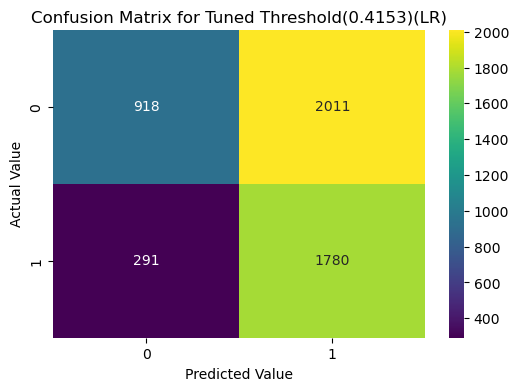


Comparison of Metrics With and Without Threshold Tuning


,Model,Precision(Churn),Recall(Churn),F1-Score(Churn),False Negatives(Missed Churn),False Positives(False Alarms)
0,Logistic Regression(Without threshold tuning),0.53,0.61,0.57,809,1123
1,Logistic Regression(With threshold tuning)(0.4...,0.47,0.86,0.61,291,2011


In [25]:
# -----------------------------------------------------------------------------
# Threshold Optimization:
# -----------------------------------------------------------------------------
test_data = pd.concat([X_test, y_test], axis=1)
y_pred_proba_lr = tuned_lr.predict_proba(X_test_scaled)[:,1]

print('\nTuning Threshold..')

# Get precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_lr)

# Calculate F1-Score
f1_scores = 2*(precision * recall) / (precision + recall)

# Find best f1-score index:
best_f1_index = np.argmax(f1_scores[:-1])

# Best Threshold:
best_threshold = thresholds[best_f1_index]
print(f'Best Threshold for Maximum F1-Score: {best_threshold:.4f}')
print(f'Recall Achieved at Best Threshold:   {recall[best_f1_index]:.4f}')

# Evaluation metrics of Threshold Tuned Model
prediction = (y_pred_proba_lr >= best_threshold).astype(int)

print(f'\nClassification Report for Best-Threshold({best_threshold:.4f})')
print(classification_report(y_test, prediction))

confusion_thresh = confusion_matrix(y_test, prediction)
plt.figure(figsize = (6,4))
sns.heatmap(confusion_thresh, annot=True, cmap='viridis', fmt='d')
plt.title(f'Confusion Matrix for Tuned Threshold({best_threshold:.4f})(LR)')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()


# Comparison of metrics with and without threshold tuning:
precision_th = round(precision_score(y_test, prediction),2)
recall_th = round(recall_score(y_test,prediction),2)
f1_th = round(f1_score(y_test,prediction),2)
fn_th, fp_th = confusion_thresh[1,0], confusion_thresh[0,1]

table = pd.DataFrame({
    'Model':['Logistic Regression(Without threshold tuning)', f'Logistic Regression(With threshold tuning)({best_threshold:.4f})'],
    'Precision(Churn)':[precision_lr, precision_th],
    'Recall(Churn)':[recall_lr, recall_th],
    'F1-Score(Churn)':[f1_lr, f1_th],
    'False Negatives(Missed Churn)':[fn_lr, fn_th],
    'False Positives(False Alarms)':[fp_lr, fp_th]
})

print('\nComparison of Metrics With and Without Threshold Tuning')
table

**Threshold Tuning Evaluation:** <br>
- After threshold tuning, the model achieved a **high recall of 0.86**, significantly improving churn detection and reducing missed churners. This aligns with the objective of early identification of high-risk customers. <br>
- However, this improvement came at the cost of a *large increase in false positives*, resulting in **low precision(0.47)** and poor retention efficiency. The model classified a large number of non-churn customers as churn, which would lead to *increased operational and marketting costs*. <br>
- The business objective includes both maximizing churn detection and improving retention efficiency, the selected **threshold(0.4154) is not optimal for deployment**. <br>
- A **segment-based targeting strategy** is recommended to ensure that high-risk customers are identified while maintaining operational efficiency.

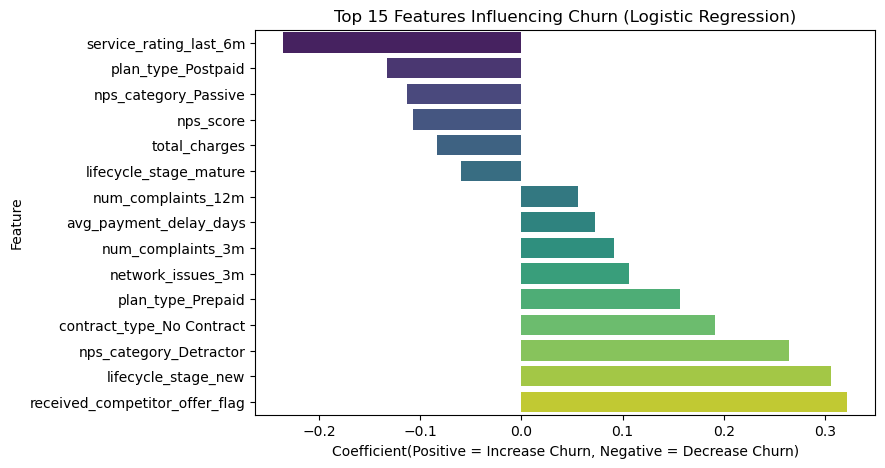

In [26]:
# -----------------------------------------------------------------------------
# Feature Importance for Tuned Logistic Regression (with FE)
# -----------------------------------------------------------------------------
coefficients = np.round(tuned_lr.coef_[0],4)
feature_names = X_train_en.columns
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
feature_importance['Importance'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by = 'Importance', ascending=False)

# Visualization
top_features = feature_importance.head(15).sort_values(by = 'Coefficient')
plt.figure(figsize = (8,5))
sns.barplot(x='Coefficient', y='Feature', data = top_features, palette = 'viridis')
plt.title('Top 15 Features Influencing Churn (Logistic Regression)')
plt.xlabel('Coefficient(Positive = Increase Churn, Negative = Decrease Churn)')
plt.ylabel('Feature')
plt.show()

## **Business Interpretation of Finalized Model (Tuned Logistic Regression (with FE))**

### Moderate Predictive Capability
The Tuned Logistic Regression Model achieves a *ROC-AUC of 0.66* and a *Churn F1-Score of 0.57*, indicating moderate predictive performance. <br>
This reflect that the model is able to capture some meaningful churn patterns, but the separation between churner and non-churner is *relatively weak.* <br>
- *This is not a model problem - It is primarily due to* **data limitations.**

### Dataset Limitation 
The dataset lacks strong predictive signals. As a result, feature engineering was able to improve model performance, but only up to a certain limit. This indicates that the model is **data-constrained**, not algorithm-constrained. Even advanced models (RF, XGBoost) show similar performance.

### Balanced Performance
- **Churn Recall: 0.61** - The model identifies a majority of churn customers.
- **Churn Precision: 0.53** - Slightly more than half of predicted churners are correct.
- The model is *effective in detecting churners*. But includes *some false positives*, leading to moderate campaign cost.

### Key Drivers of Churn (Feature - Based Insights)
**Strong Churn Drivers:** <br>
- Customers receiving **competitor offers** (highest impact).
- **New customers(Tenure <= 12 months)**.
- **Prepaid plan users**.
- Customers with **low NPS/dissatisfaction**.
- **Frequent complaints/network issues**.
This Indicates churn is driven by **competition, dissatisfaction, and weak early-stage engagement**.

**Strong Retention Drivers**
- High **service rating and NPS score**.
- **Postpaid customers**.
- Customers with **long tenure/high total charges**.
- Mature lifecycle customers (tenure > 24 months).
- This indicate loyalty increases with **satisfaction, tenure, and engagement**.

In [27]:
# -----------------------------------------------------------------------------
# Top N Targeting for High-Value Segment Customers
# -----------------------------------------------------------------------------
test_data = pd.concat([X_test, y_test], axis = 1)
test_data['churn_prob'] = tuned_lr.predict_proba(X_test_scaled)[:,1]

high_value = test_data[test_data['segment_value'] == 'High']
high_val_sorted = high_value.sort_values(by = 'churn_prob', ascending = False)

# Total churn in high value segment
total_churn_high = high_value['is_churn'].sum()
churn_rate_actual = round(high_value['is_churn'].mean() * 100, 2)

# Top 30% Customers
top_30_percent_customers = high_val_sorted.head(int(len(high_val_sorted) * 0.30))
customers_targeted_30 = len(top_30_percent_customers)
churn_rate_30 = round(top_30_percent_customers['is_churn'].mean() * 100 , 2)
churn_captured_30 = top_30_percent_customers['is_churn'].sum()

# Top 50% Customers
top_50_percent_customers = high_val_sorted.head(int(len(high_val_sorted) * 0.50))
customers_targeted_50 = len(top_50_percent_customers)
churn_rate_50 = round(top_50_percent_customers['is_churn'].mean() * 100 , 2)
churn_captured_50 = top_50_percent_customers['is_churn'].sum()



result_table = {
    'Target Group': ['Top30%', 'Top50%', 'All Customers'],
    'Customers Targeted': [customers_targeted_30, customers_targeted_50, len(high_value)],
    'Churn Captured': [churn_captured_30, churn_captured_50, total_churn_high],
    'Churn Rate (%)': [churn_rate_30, churn_rate_50, churn_rate_actual]
}

results_df = pd.DataFrame(result_table)
print('\nTop-N Churn Targeting Performance for High-Value Customers:')
print(f'{"-"*65}\n')
print(results_df.to_string(index = False))


Top-N Churn Targeting Performance for High-Value Customers:
-----------------------------------------------------------------

 Target Group  Customers Targeted  Churn Captured  Churn Rate (%)
       Top30%                 176              76           43.18
       Top50%                 293             111           37.88
All Customers                 587             184           31.35


<div style="background-color:#235543; color:white; padding:10px; border-radius:5px; font-size:30px;">
<strong>ADVICES AND ACTIONS SUGGESTED FOR BUSINESS</strong>
</div>

The recommendations are structured into **strategic actions (model usage)** and **operational actions (based on churn drivers and segment insights)**, while considering **moderate model performance and dataset limitations.**

---

### A. Strategic Recommendations (Based on model performance)
**1. Deploy as Decision-Support System (Not Fully Automated)**
- Integrate the churn model into the *CRM system* for periodic scoring (e.g., monthly/weekly).
- Use predictions to **assist decision-making**, not fully automate actions. <br>
- The model has **moderate predictive power(AUC = 0.66)**, so it should support, not replace business judgement.

**2. Implement Risk-Based Customer Segmentation** <br>
For **Low-Value** & **Medium-Value Customer Segments** use predicted probabilities to create risk tiers:

| **Risk Tier** | **Probability Range** | **Recommended Action** |
|---------------|-----------------------|------------------------|
| **Critical Risk** | >0.60 | Apply aggressive, personalized retention campaigns (e.g., high value discounts, personal outreach from senior representatives). |
| **High Risk** | 0.50 - 0.60 | Strong interventions for Medium Value Segment like offers, discounts and use cost effective, automated interventions (e.g., personalized emails, rewards, new feature highlights) for low-value segment.
| **Medium Risk** | 0.45 - 0.50 | For medium-value segment only apply engagement campaigns like personalized emails, loyalty reward and new feature highlights.
| **Low Risk** | <0.45 | No immediate actions.

Since model confidence is moderate, aggressive thresholds like 0.9 are avoided. <br>

---

### **Top-N Targeting Strategy for High-Value Segment Customers** 
Instead of applying churn predictions uniformly across all customers, a **Top-N targeting strategy is specifically recommended for high-value segment**, where business impact is high.

**Reason of special treatment for High-Value Segment** <br>
The model's **recall for high-value customers is only 17%**. This indicates the model struggles to directly identify churners in this segment likely due to *limited signals in the dataset*. Therefore, relying only on binary predictions(0/1) is not effective for high-value customers.

**Solution: Probability-Based Top-N Targeting** <br>
Instead of classification, customers are **ranked by predicted churn probability**. Top N% customers are selected for intervention. 
- **Observed Results (High-value segment)**
| **Target Group** | **Churn Rate** |
|------------------|----------------|
| **Actual Churn Rate** | **31%** |
| **Top 30% High-Risk Customers** | **43%** |
| **Top 50% High-Risk Customers** | **38%** |

The model is **weak at classification (low-recall = 17%)**, but **strong at ranking customers by risk.** For **top 30%** customers the **churn rate is 43%** *which is higher than baseline 31%(means if customers are targeted randomly the churn rate among them will be 31% but with the help of ML Model the churn rate will be 43%, by this we will be able to target more efficiently)*. Even top 50% have churn rate of 38%. <br>
Even though the model cannot accurately classify all churners, it can still **prioritize high-risk customers effectively.** <br>


**Business Strategy for High-value Customers:** 
- Focus on **Top 30% high-risk high-value customers**. Apply **strong retention strategy** (e.g., personalized retention campaigns, high-value discounts, personal outreach by representatives).
- **Expand to Top 50%**, apply engagement campaigns like personalized emails, loyalty rewards, discounts, new-feature early access.

This ensures **optimal resource utilization** and **targeted retention spending**

---

### B. Operational Actions (Based on Feature Importance Insights)

---

**1. Competitor Offer Response Strategy:** 
Customers receiving competitor offers shows **highest churn risk**.
- **Action:**Identify customers receiving **competitor offers** and respond with **personalized counter-offers**(discounts, bundled plans, loyalty rewards).
    - Example: *"Stay with us and get 20% off + free OTT bundle."*
- Prioritize **high-value, high-risk, critical-risk customers** for immediate outreach.
- **Rationale:** Competitor offers are the strongest churn trigger - fast and targeted response can directly prevent customers loss.

---

**2. Improve Customer Experience:** 
- **Action:** Address key pain points such as **network issues, high complaint frequency, and poor service ratings.**
    - Reduce complaint **resolution time**.
    - Provide **proactive support** to frequent complainers.
    - Continuously monitor **service quality metrics**.
- **Rationale:** Poor experience directly drives churn - improving service reliability increases customer trust and retention.

---

**3. Strengthen Early Customer Engagement:**
- **Action:** Focus on **new customers** with structured onboarding programs.
    - Implement **first 30-90 day engagement plans.**
    - Offer **welcome benefits and onboarding calls.**
- **Rationale:** New customers have **highest churn rate** due to weak initial experience - early engagement builds loyalty and reduce early drop-offs.

---

**4. Plan-Type Optimization:**
- **Action:** Target **critical and high-risk prepaid customers** and encourage migration to **postpaid or long-term plans.**
    - Example: *"Switch to a 1-year plan and get a free device upgrade."*
- Offer **bundled incentives** for longer commitments.
- **Rationale:** 'Plan type-Prepaid' is a strong churn predictor - **long term contracts increase stability and reduce churn.**

---

**5. Improve customer satisfaction:**
- **Action:** Identify **low NPS(detractors)** early and run targeted satisfaction improvement campaigns.
    - Personalized outreach.
    - Issue resolution prioritization.
    - Feedback-driven service improvements.
- **Rationale:** Dissatisfied customers are highly likely to churn - converting detractors into promoters directly improves retention.

---

**Summary:** <br>
By combining **proactive retention strategies**(competitor response, onboarding, satisfaction improvement) with **structural changes**(plan optimization, service quality enhancement), ConnectTel can turn churn insights into **actionable interventions** that significantly improve **customer retention and long-term profitability.**

---

In [28]:
# -----------------------------------------------------------------------------
# BUSINESS IMPACT QUANTIFICATION
# -----------------------------------------------------------------------------

total_customers = len(data)
churned_customers = data['is_churn'].sum()
avg_arpu_churned = data[data['is_churn']==1]['arpu'].mean()

# Total aanual revenue at risk (if all churners leave)
annual_revenue_at_risk = churned_customers * avg_arpu_churned * 12

# ------------------------------------------
# Full Model (Recall Based Targeting)
# ------------------------------------------
# Model Performance:
model_recall = 0.61        # Tuned LR recall
customers_identified = int(churned_customers * model_recall)

# Conservative retention assumption: 35% of identified churners retained
retention_rate = 0.35
customers_retained = int(customers_identified * retention_rate)

# Annual revenue saved
annual_revenue_saved = customers_retained * avg_arpu_churned * 12

print(f'\n{"="*65}')
print('--- ESTIMATED BUSINESS IMPACT OF CHURN MODEL DEPLOYMENT ---')
print(f'{"="*65}')
print(f'Total customers at risk (actual churner):      {churned_customers}')
print(f'Total annual revenue at risk:                  Rs.{annual_revenue_at_risk/1e7:.2f} Crore per year')
print(f'\nCustomers identified by model (61% recall):    {customers_identified}')
print(f'Customers retained (35% success rate assumed): {customers_retained}')
print(f'\nAverage ARPU (churned customers):              Rs.{avg_arpu_churned:.0f}/-')
print(f'\nEstimated annual revenue saved:                Rs.{annual_revenue_saved / 1e7:.2f} Crore per year')
print(f'Revenue risk mitigated:                        {(annual_revenue_saved / annual_revenue_at_risk) * 100 :.2f}%')
print(f'{"="*65}')

print('\nNOTE: Retention success rate of 35% is conservative.')
print('Industry benchmarks for targeted telecom retention campaigns range from 25% - 45%.')


--- ESTIMATED BUSINESS IMPACT OF CHURN MODEL DEPLOYMENT ---
Total customers at risk (actual churner):      10357
Total annual revenue at risk:                  Rs.5.59 Crore per year

Customers identified by model (61% recall):    6317
Customers retained (35% success rate assumed): 2210

Average ARPU (churned customers):              Rs.450/-

Estimated annual revenue saved:                Rs.1.19 Crore per year
Revenue risk mitigated:                        21.34%

NOTE: Retention success rate of 35% is conservative.
Industry benchmarks for targeted telecom retention campaigns range from 25% - 45%.


<div style="background-color:#235543; color:white; padding:10px; border-radius:5px; font-size:22px;">
<strong>Business Impact Quantification of Churn Model</strong>
</div>

The purpose of this analysis is to *translate model performance into real business value,* by estimating how much revenue can be *protected through targeted retention strategies*.

**Revenue at Risk:**
- The total number of **actual churn customers is 10,357**.
- The **average ARPU of churned customers is Rs.450 per month**.
- This results in a **total annual revenue at risk of Rs.5.59 Crore**. <br>
This represents the **maximum potential loss** if no intervention is applied.

**Model Contribution to Churn Reduction**
- The selected model **(Tuned Logistic Regression)** achieves a **recall of 61%**.
- This means the model can identify approximately **6317 potential churn customers.** <br>
These customers become the **target group for retention campaigns.**

**Retention Assumption**
- A **conservative retention success rate of 35%** is assumed.
- Based on this, **2210** customers can be retained. <br>
This assumption ensures that the estimated impact is **realistic and not over-optimistic**.

**Estimated Revenue Saved**
- Each retained customer contributes: Rs.450/month * 12 = Rs.5400/- annually.
- Total estimated annual revenue saved: Rs.1.19 Crore per year.

**Key Insight**
- Out of **Rs.5.59 Crore revenue at risk**, the model helps recover approximately **Rs.1.19 Crore.**
- This corresponds to approximately **21% revenue risk mitigation.** <br>
This demonstrates that even with **moderate model performance**, the business impact is **significant.**